# GOAL
- FIND THE PARENT OF SISTER AFFILIATES

# CONFIG

In [304]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import rcParams
from tabulate import tabulate
import itertools

warnings.filterwarnings('ignore')

sys.modules.pop('a20_config.a10_config', None)  # force reload
from a20_config.a10_config import dyr, file, const, var, fi, c, v

print('CWD:', Path.cwd())
assert Path.cwd() == dyr.project_root, "Please set the working directory to the project root"
print("CWD is the project root, GOOD!")

CWD: /sharedata/camm/c_projects/i100_g7__VC_arms
CWD is the project root, GOOD!


# PIPELINE
## Find Parents

In [106]:
# read the clean affiliation data -- only VC and hospital, all are pairs, clean
df00_cad = pd.read_excel(file.dp_sp060_10__all_hospitals_and_VC_affiliations__final__xl)

print(len(df00_cad))

t1_n_pairs = df00_cad[var.pair_id].nunique()
t1_n_pairs_name = 'Total number of pairs (both sisters and parent-subsidiary)'
print(f'{t1_n_pairs_name}: {t1_n_pairs}')

df00_cad

454
Total number of pairs (both sisters and parent-subsidiary): 227


,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,HQCountry,LastUpdated,affiliate_type,entity_type,FromPitchBook,not_valid_affiliation_type
0,0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,United States,05/06/2023,hospital,vc,True,NaN
1,0,166514-86,434783-53,Ballad Ventures,Corporate Venture Capital,"Johnson City, TN",2020.0,Subsidiary,Johnson City,Tennessee,United States,01/30/2023,vc,hospital,True,NaN
2,1,62802-10,57221-29,Bank Austria TFV,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,Austria,01/30/2023,vc,hospital,True,NaN
3,1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,France,03/02/2023,hospital,vc,True,NaN
4,2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,NaN,05/06/2023,hospital,vc,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,251,527371-30,64863-82,NaN,NaN,NaN,NaN,Sister,NaN,NaN,NaN,NaN,hospital,vc,False,NaN
450,252,62848-00,111991-60,Netdoktor.at,Other Healthcare Services,"Vienna, Austria",2001.0,Sister,Vienna,NaN,Austria,01/30/2023,hospital,vc,False,NaN
451,252,111991-60,62848-00,DLD Ventures,Corporate Venture Capital,"Munich, Germany",2007.0,Sister,Munich,NaN,Germany,01/30/2023,vc,hospital,True,NaN
452,253,157276-27,166341-79,Oravision Ventures,Corporate Venture Capital,"Andover, MA",NaN,Subsidiary,Andover,Massachusetts,United States,01/30/2023,vc,hospital,True,NaN


In [107]:
print(df00_cad[v.aff_type].value_counts())

AffiliateType
Sister        378
Parent         38
Subsidiary     38
Name: count, dtype: int64


In [108]:
# number of parent-subsidiary pairs

msk = df00_cad[var.aff_type].isin([c.par, c.sub])
df00_par = df00_cad[msk]
print(len(df00_par))

t1_n_parent_subsidiary_pairs = df00_par[var.pair_id].nunique()
t1_n_parent_subsidiary_pairs_name = 'Unique parent-subsidiary pairs (based on unique pair_id)'
print(f'{t1_n_parent_subsidiary_pairs_name}: {t1_n_parent_subsidiary_pairs}')

76
Unique parent-subsidiary pairs (based on unique pair_id): 38


In [109]:
# keep only sister pairs
_msk = df00_cad[var.aff_type].eq(const.sis)

df01_sis = df00_cad[_msk]
print(len(df01_sis))

t1_n_unique_sis_pairs = df01_sis[var.pair_id].nunique()
t1_n_unique_sis_pairs_name = 'Unique sister pairs (based on unique pair_id)'
print(f'{t1_n_unique_sis_pairs_name}: {t1_n_unique_sis_pairs}')

t1_unique_sis_entity_ids = df01_sis[var.entity_id].nunique()
t1_unique_sis_entity_ids_name = 'Unique sister entity IDs (based on unique entity_id)'
print(f'{t1_unique_sis_entity_ids_name}: {t1_unique_sis_entity_ids}')

# suppose I have both the go and back of a pair, how can the number of unique entity IDs be more than half of the number of pair IDs?
#   - Some IDs must be sisters to more than one other ID

# Is it sound to say that if one entity is a sister to two other IDs then those two are also sisters to each other? Do we have transitivity?
#   - NO, not necessarily. we can have partial ownership structure or multilevel parents

378
Unique sister pairs (based on unique pair_id): 189
Unique sister entity IDs (based on unique entity_id): 243


In [110]:
# read the original affiliation data,
#  - which has more entities and relationships, but also has some dirty data, I will use this to find the parents of the sister affiliates.
df05_oad = pd.read_parquet(file.pb_ent_aff_rel__parq)
print(len(df05_oad))

1622354


In [111]:
# I want to find the parents of the sister pairs, so their parent id will be in the affiliateID column of the original affiliation data and their IDs would be in the entitiy ID so I jsut keep the rows where the entitiy ID is in the df00 entitiy IDs, because all unique enitites appear once in enitity ID column and once in the affiliateID column I don't need to worry about missing any ID, the entity ID is enough and containts all the unique IDs for all sister pairs

df10_oad_sis = df05_oad[df05_oad[var.entity_id].isin(df01_sis[var.entity_id])]
print(len(df10_oad_sis))

3986


In [112]:
# Now because I want the parent of the sister pairs I should only keep affiliate IDs that has only the parent affiliate type

df10_oad_sis = df10_oad_sis[df10_oad_sis[var.aff_type].eq(const.par)]
print(len(df10_oad_sis))

238


In [113]:
# find parent of each entity
# - For each unique entity ID in the sister pairs, I identify its unique parent affiliate IDs.
# - If an entity maps to exactly one parent affiliate ID, I assign it as the parent.

# Create a copy of df01 to work with
df02 = df01_sis.copy()

# Get all columns from df10 that we'll need to add with _par suffix
parent_cols = [col for col in df10_oad_sis.columns if col != var.entity_id]

# Initialize new columns for parent data with NaN values
for col in parent_cols:
    df02[f"{col}_par"] = np.nan

# Set default value for AffiliateID_par to 'no_parent_found'
df02[f'{v.aff_type}_par'] = "no_parent_found"

# Iterate through each row in df01
for idx, row in df01_sis.iterrows():
    entity_id = row[var.entity_id]

    # Find all matching rows for this entity ID
    matching_parents = df10_oad_sis[df10_oad_sis[var.entity_id] == entity_id]

    # Assert that we have at most 1 parent row
    assert len(matching_parents) <= 1, f"Entity ID {entity_id} has {len(matching_parents)} parents, expected 0 or 1"

    # If we found a parent, add its data to df02
    if len(matching_parents) == 1:
        parent_row = matching_parents.iloc[0]

        # Add all parent columns with _par suffix
        for col in parent_cols:
            df02.at[idx, f"{col}_par"] = parent_row[col]

print(f"{len(df02)} rows")
print(f"Parent columns added: {[col for col in df02.columns if col.endswith('_par')]}")
print(len(df02.columns.tolist()), "columns in df02")
df02

378 rows
Parent columns added: ['AffiliateID_par', 'AffiliateName_par', 'Industry_par', 'Location_par', 'YearFounded_par', 'AffiliateType_par', 'HQCity_par', 'HQState_Province_par', 'HQCountry_par', 'LastUpdated_par']
26 columns in df02


,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,...,AffiliateID_par,AffiliateName_par,Industry_par,Location_par,YearFounded_par,AffiliateType_par,HQCity_par,HQState_Province_par,HQCountry_par,LastUpdated_par
2,1,62802-10,57221-29,Bank Austria TFV,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,...,11215-09,3i Group,PE/Buyout,"London, United Kingdom",1945.0,Parent,London,England,United Kingdom,01/30/2023
3,1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,...,11215-09,3i Group,PE/Buyout,"London, United Kingdom",1945.0,Parent,London,England,United Kingdom,01/30/2023
14,11,55440-55,62517-16,Allegheny Health Network,Hospitals/Inpatient Services,"Pittsburgh, PA",1999.0,Sister,Pittsburgh,Pennsylvania,...,52465-06,Highmark,Life and Health Insurance,"Pittsburgh, PA",1996.0,Parent,Pittsburgh,Pennsylvania,United States,01/30/2023
15,11,62517-16,55440-55,Highmark Health Ventures,Venture Capital,"Pittsburgh, PA",1990.0,Sister,Pittsburgh,Pennsylvania,...,52465-06,Highmark,Life and Health Insurance,"Pittsburgh, PA",1996.0,Parent,Pittsburgh,Pennsylvania,United States,01/30/2023
16,12,183796-03,55472-23,Health Insight Capital,Corporate Venture Capital,"Nashville, TN",NaN,Sister,Nashville,Tennessee,...,10441-90,HCA Management Services,Hospitals/Inpatient Services,"Nashville, TN",1968.0,Parent,Nashville,Tennessee,United States,01/30/2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,250,114336-37,527371-30,Catalyst by Wellstar,Corporate Venture Capital,"Marietta, GA",2021.0,Sister,Marietta,Georgia,...,64863-82,Wellstar Health System,Clinics/Outpatient Services,"Marietta, GA",1997.0,Parent,Marietta,Georgia,United States,05/06/2023
448,251,64863-82,527371-30,Catalyst by Wellstar,Corporate Venture Capital,"Marietta, GA",2021.0,Sister,Marietta,Georgia,...,NaN,NaN,NaN,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN
449,251,527371-30,64863-82,NaN,NaN,NaN,NaN,Sister,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN
450,252,62848-00,111991-60,Netdoktor.at,Other Healthcare Services,"Vienna, Austria",2001.0,Sister,Vienna,NaN,...,NaN,NaN,NaN,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN


## Data Checks & Counts

In [114]:
_afftype_par = f'{var.aff_type}_par'

t1_n_uniq_ent_with_parent_in_sis_name = 'Number of Unique Entities in Sister Pairs with found parent'
t1_n_uniq_ent_with_parent_in_sis = df02[df02[_afftype_par] != "no_parent_found"][var.entity_id].nunique()
print(f"{t1_n_uniq_ent_with_parent_in_sis_name}: {t1_n_uniq_ent_with_parent_in_sis}")

t1_n_uniq_ent_without_parent_in_sis_name = 'Number of Unique Entities in Sister Pairs without parent'
t1_n_uniq_ent_without_parent_in_sis = df02[df02[_afftype_par] == "no_parent_found"][var.entity_id].nunique()
print(f"{t1_n_uniq_ent_without_parent_in_sis_name}: {t1_n_uniq_ent_without_parent_in_sis}")

Number of Unique Entities in Sister Pairs with found parent: 238
Number of Unique Entities in Sister Pairs without parent: 5


In [115]:
# Because I iterated over all the unique entities, one unique entity cannot have both parent and no parent situation. So there is no need to check for this.

# But still one can have no_parent_found status, while its sister has a parent. YES THIS CAN HAPPEN AND HAPPENED.
# - Do not fill in this type of situation just leave it as it is, because I don't want to make any assumption about the parent of the sister pair if one of them has no parent found, I will just leave it as it is and only fill in the parent information for those sister pairs where both of them have found parents and they are the same, just count how

# Just count how many have no parent and how many its sister have parent but they themselves don't have parent

df02[df02[_afftype_par] == "no_parent_found"]

,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,...,AffiliateID_par,AffiliateName_par,Industry_par,Location_par,YearFounded_par,AffiliateType_par,HQCity_par,HQState_Province_par,HQCountry_par,LastUpdated_par
403,227,513338-32,11259-10,NaN,NaN,NaN,NaN,Sister,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN
443,248,158931-46,125942-95,Medsi Group,Clinics/Outpatient Services,"Moscow, Russia",1996.0,Sister,Moscow,NaN,...,NaN,NaN,NaN,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN
446,250,527371-30,114336-37,NaN,NaN,NaN,NaN,Sister,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN
448,251,64863-82,527371-30,Catalyst by Wellstar,Corporate Venture Capital,"Marietta, GA",2021.0,Sister,Marietta,Georgia,...,NaN,NaN,NaN,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN
449,251,527371-30,64863-82,NaN,NaN,NaN,NaN,Sister,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN
450,252,62848-00,111991-60,Netdoktor.at,Other Healthcare Services,"Vienna, Austria",2001.0,Sister,Vienna,NaN,...,NaN,NaN,NaN,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN


In [116]:
# count the number of parents found for each pair ID (possible to be the same but still 2 found, not unique necessarily here)

pair_parent_counts = df02.groupby(var.pair_id)[_afftype_par].apply(lambda x: (x != "no_parent_found").sum())
df02[v.pair_parent_count] = df02[var.pair_id].map(pair_parent_counts)

t1_n_0_par_pairs_name = 'Number of Sister pairs with 0 parents found'
t1_n_0_par_pairs = (pair_parent_counts == 0).sum()
print(f"{t1_n_0_par_pairs_name}: {t1_n_0_par_pairs}")

t1_n_1_par_pairs_name = 'Number of Sister pairs with 1 parent found'
t1_n_1_par_pairs = (pair_parent_counts == 1).sum()
print(f"{t1_n_1_par_pairs_name}: {t1_n_1_par_pairs}")

t1_n_2_par_pairs_name = 'Number of Sister pairs with 2 parent found'
t1_n_2_par_pairs = (pair_parent_counts == 2).sum()
print(f"{t1_n_2_par_pairs_name}: {t1_n_2_par_pairs}")

pair_parent_counts

Number of Sister pairs with 0 parents found: 1
Number of Sister pairs with 1 parent found: 4
Number of Sister pairs with 2 parent found: 184


pair_id
1      2
11     2
12     2
13     2
14     2
      ..
243    2
248    1
250    1
251    0
252    1
Name: AffiliateType_par, Length: 189, dtype: int64

In [117]:
# count unique found parents in sister pairs

df03 = df02[df02[_afftype_par] != "no_parent_found"].copy()

pair_uniq_par_counts = df03.groupby(var.pair_id)[_afftype_par].apply(lambda x: len(x.unique()))

df02[v.pair_uniq_parent_count] = df02[var.pair_id].map(pair_uniq_par_counts)

pair_uniq_par_counts

pair_id
1      1
11     1
12     1
13     1
14     1
      ..
242    1
243    1
248    1
250    1
252    1
Name: AffiliateType_par, Length: 188, dtype: int64

In [118]:
print("Verify that all pairs with 2 parents found have 1 unique parent")
pairs_with_2_parents = df02[df02[v.pair_parent_count] == 2]

t1_b_are_all_2_par_pairs_have_1_unique_parent_name = 'All sister pairs with 2 parents found have 1 unique parent?'
t1_b_are_all_2_par_pairs_have_1_unique_parent = pairs_with_2_parents[var.pair_uniq_parent_count].eq(1).all()
print(f"{t1_b_are_all_2_par_pairs_have_1_unique_parent_name} : {t1_b_are_all_2_par_pairs_have_1_unique_parent}")

Verify that all pairs with 2 parents found have 1 unique parent
All sister pairs with 2 parents found have 1 unique parent? : True


In [119]:
msk = df02[v.pair_parent_count].eq(2)
msk &= df02[v.pair_uniq_parent_count].eq(1)

df02.loc[msk, v.both_sisters_have_same_parent] = True
print(f"Marked {msk.sum()} rows where both sisters have the same parent")

Marked 368 rows where both sisters have the same parent


In [120]:
df02

,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,...,Location_par,YearFounded_par,AffiliateType_par,HQCity_par,HQState_Province_par,HQCountry_par,LastUpdated_par,pair_parent_count,pair_uniq_parent_count,both_sisters_have_same_parent
2,1,62802-10,57221-29,Bank Austria TFV,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,...,"London, United Kingdom",1945.0,Parent,London,England,United Kingdom,01/30/2023,2,1.0,True
3,1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,...,"London, United Kingdom",1945.0,Parent,London,England,United Kingdom,01/30/2023,2,1.0,True
14,11,55440-55,62517-16,Allegheny Health Network,Hospitals/Inpatient Services,"Pittsburgh, PA",1999.0,Sister,Pittsburgh,Pennsylvania,...,"Pittsburgh, PA",1996.0,Parent,Pittsburgh,Pennsylvania,United States,01/30/2023,2,1.0,True
15,11,62517-16,55440-55,Highmark Health Ventures,Venture Capital,"Pittsburgh, PA",1990.0,Sister,Pittsburgh,Pennsylvania,...,"Pittsburgh, PA",1996.0,Parent,Pittsburgh,Pennsylvania,United States,01/30/2023,2,1.0,True
16,12,183796-03,55472-23,Health Insight Capital,Corporate Venture Capital,"Nashville, TN",NaN,Sister,Nashville,Tennessee,...,"Nashville, TN",1968.0,Parent,Nashville,Tennessee,United States,01/30/2023,2,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,250,114336-37,527371-30,Catalyst by Wellstar,Corporate Venture Capital,"Marietta, GA",2021.0,Sister,Marietta,Georgia,...,"Marietta, GA",1997.0,Parent,Marietta,Georgia,United States,05/06/2023,1,1.0,NaN
448,251,64863-82,527371-30,Catalyst by Wellstar,Corporate Venture Capital,"Marietta, GA",2021.0,Sister,Marietta,Georgia,...,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN,0,NaN,NaN
449,251,527371-30,64863-82,NaN,NaN,NaN,NaN,Sister,NaN,NaN,...,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN,0,NaN,NaN
450,252,62848-00,111991-60,Netdoktor.at,Other Healthcare Services,"Vienna, Austria",2001.0,Sister,Vienna,NaN,...,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN,1,1.0,NaN


## Merge Parents Back
ADD PARENT INFORMATION BACK TO THE ORIGINAL AFFILIATION DATA

In [121]:
# concat the sisters df02 with their parent info to the parent-subsidiary subset of the cleaned aff data, vertically
# - There is no common rows between the two and both will construct the original cleaned affiliation data with parent info added for sister pairs
# - for parent subsidiary pairs, new column will have nan values.

# df02: sis pairs with parent info added, but only has sister pairs
# df00_par: parent-subsidiary pairs, but no parent info added, has only parent-subsidiary pairs

# concat vertically
df04 = pd.concat([df02, df00_par], ignore_index = True)
df04 = df04.sort_values([v.pair_id])

print(len(df04))
print(len(df00_cad))
df04

454
454


,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,...,Location_par,YearFounded_par,AffiliateType_par,HQCity_par,HQState_Province_par,HQCountry_par,LastUpdated_par,pair_parent_count,pair_uniq_parent_count,both_sisters_have_same_parent
378,0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
379,0,166514-86,434783-53,Ballad Ventures,Corporate Venture Capital,"Johnson City, TN",2020.0,Subsidiary,Johnson City,Tennessee,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,1,62802-10,57221-29,Bank Austria TFV,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,...,"London, United Kingdom",1945.0,Parent,London,England,United Kingdom,01/30/2023,2.0,1.0,True
1,1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,...,"London, United Kingdom",1945.0,Parent,London,England,United Kingdom,01/30/2023,2.0,1.0,True
380,2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,251,527371-30,64863-82,NaN,NaN,NaN,NaN,Sister,NaN,NaN,...,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN,0.0,NaN,NaN
376,252,62848-00,111991-60,Netdoktor.at,Other Healthcare Services,"Vienna, Austria",2001.0,Sister,Vienna,NaN,...,NaN,NaN,no_parent_found,NaN,NaN,NaN,NaN,1.0,1.0,NaN
377,252,111991-60,62848-00,DLD Ventures,Corporate Venture Capital,"Munich, Germany",2007.0,Sister,Munich,NaN,...,"Munich, Germany",1903.0,Parent,Munich,None,Germany,01/30/2023,1.0,1.0,NaN
453,253,166341-79,157276-27,Ora Clinical,Other Healthcare Services,"Andover, MA",1985.0,Parent,Andover,Massachusetts,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
print(df04.columns)
print(len(df04))

Index(['pair_id', 'EntityID', 'AffiliateID', 'AffiliateName', 'Industry',
       'Location', 'YearFounded', 'AffiliateType', 'HQCity',
       'HQState_Province', 'HQCountry', 'LastUpdated', 'affiliate_type',
       'entity_type', 'FromPitchBook', 'not_valid_affiliation_type',
       'AffiliateID_par', 'AffiliateName_par', 'Industry_par', 'Location_par',
       'YearFounded_par', 'AffiliateType_par', 'HQCity_par',
       'HQState_Province_par', 'HQCountry_par', 'LastUpdated_par',
       'pair_parent_count', 'pair_uniq_parent_count',
       'both_sisters_have_same_parent'],
      dtype='object')
454


In [123]:
# keep only sister pairs with both have same parent
# the values in the v.both_sisters_have_same_parent is only true for nice sister pairs with both have a same parent and nan for parent-sub pairs and for sister pairs that have 1 parent found or no parent found. There is no sister pair with two different parents found. (which we would expect based on the definition of being a sister to each other)

print(df04[v.both_sisters_have_same_parent].value_counts())

both_sisters_have_same_parent
True    368
Name: count, dtype: int64


In [173]:
# keep only nice sister pairs from all sister pairs
df05 = df02[df02[v.both_sisters_have_same_parent].eq(True)]
print(len(df05))

# now concat df05 with df00_pair
df10 = pd.concat([df05, df00_par], ignore_index = True)
df10 = df10.sort_values([v.pair_id])

print(len(df10))

# clean affiliation data
# - with parent info added for sister pairs, but only keep sister pairs with both have same parent, and all parent-subsidiary pairs
df10.to_excel(fi.sp100_20, index = False)
print(fi.sp100_20)

368
444
/sharedata/camm/c_projects/i100_g7__VC_arms/f10_data_interim/sp100_20.xlsx


In [302]:
df10

,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,...,Location_par,YearFounded_par,AffiliateType_par,HQCity_par,HQState_Province_par,HQCountry_par,LastUpdated_par,pair_parent_count,pair_uniq_parent_count,both_sisters_have_same_parent
369,0,166514-86,434783-53,Ballad Ventures,Corporate Venture Capital,"Johnson City, TN",2020.0,Subsidiary,Johnson City,Tennessee,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,1,62802-10,57221-29,Bank Austria TFV,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,...,"London, United Kingdom",1945.0,Parent,London,England,United Kingdom,01/30/2023,2.0,1.0,True
1,1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,...,"London, United Kingdom",1945.0,Parent,London,England,United Kingdom,01/30/2023,2.0,1.0,True
370,2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,247,435249-19,435253-51,Novamind,Venture Capital,"Toronto, Canada",2019.0,Parent,Toronto,Ontario,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
441,249,164588-68,507452-14,Wanyuandia Investment,Corporate Venture Capital,"Hangzhou, China",2021.0,Subsidiary,Hangzhou,Zhejiang,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
440,249,507452-14,164588-68,NaN,NaN,NaN,NaN,Parent,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
443,253,166341-79,157276-27,Ora Clinical,Other Healthcare Services,"Andover, MA",1985.0,Parent,Andover,Massachusetts,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## T1
Table 1: Summary of Sister Pairs Parent Finding

In [125]:
print("Create a summary dataframe with counts and percentages")

_columns_t1 = ['Category', 'Count', 'BOOL']
_data_t1 = [
        [t1_n_pairs_name, t1_n_pairs, ""],
        [t1_n_parent_subsidiary_pairs_name, t1_n_parent_subsidiary_pairs, ""],
        [t1_n_unique_sis_pairs_name, t1_n_unique_sis_pairs, ""],
        [t1_n_uniq_ent_with_parent_in_sis_name, t1_n_uniq_ent_with_parent_in_sis, ""],
        [t1_n_uniq_ent_without_parent_in_sis_name, t1_n_uniq_ent_without_parent_in_sis, ""],
        [t1_n_0_par_pairs_name, t1_n_0_par_pairs, ""],
        [t1_n_1_par_pairs_name, t1_n_1_par_pairs, ""],
        [t1_n_2_par_pairs_name, t1_n_2_par_pairs, ""],
        [t1_b_are_all_2_par_pairs_have_1_unique_parent_name, "", t1_b_are_all_2_par_pairs_have_1_unique_parent],
]
df_t1 = pd.DataFrame(columns = _columns_t1, data = _data_t1)

print(tabulate(df_t1,
               headers = df_t1.columns,
               tablefmt = 'rounded_outline',
               stralign = 'left',
               numalign = 'right'))


Create a summary dataframe with counts and percentages
╭────┬─────────────────────────────────────────────────────────────┬─────────┬────────╮
│    │ Category                                                    │ Count   │ BOOL   │
├────┼─────────────────────────────────────────────────────────────┼─────────┼────────┤
│  0 │ Total number of pairs (both sisters and parent-subsidiary)  │ 227     │        │
│  1 │ Unique parent-subsidiary pairs (based on unique pair_id)    │ 38      │        │
│  2 │ Unique sister pairs (based on unique pair_id)               │ 189     │        │
│  3 │ Number of Unique Entities in Sister Pairs with found parent │ 238     │        │
│  4 │ Number of Unique Entities in Sister Pairs without parent    │ 5       │        │
│  5 │ Number of Sister pairs with 0 parents found                 │ 1       │        │
│  6 │ Number of Sister pairs with 1 parent found                  │ 4       │        │
│  7 │ Number of Sister pairs with 2 parent found                


✓ Table saved to: /sharedata/camm/c_projects/i100_g7__VC_arms/g22_result_table_pics/sp100_10__t1.svg


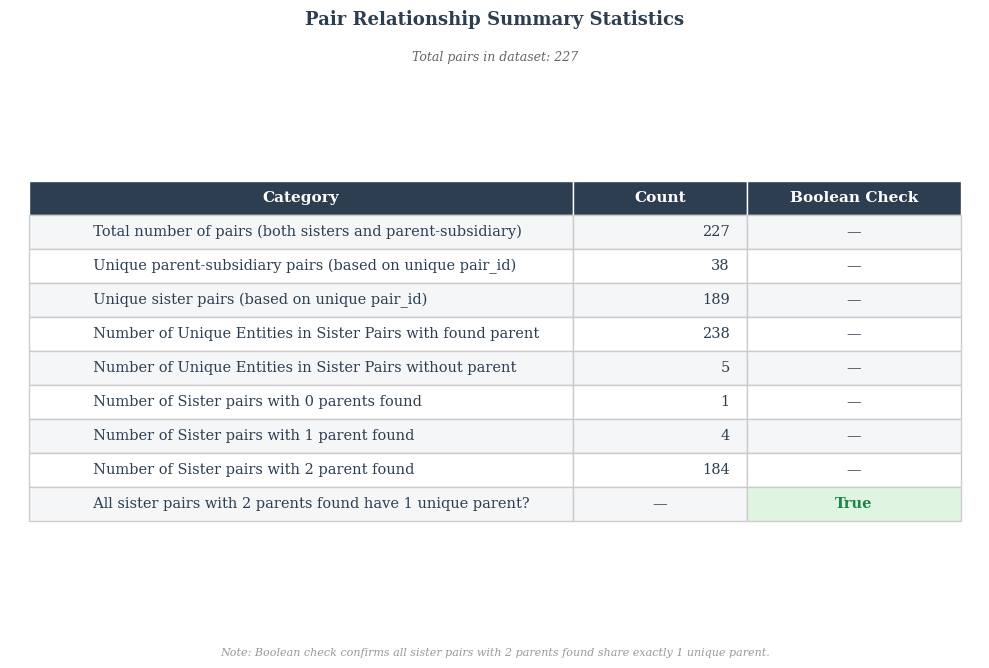

In [126]:
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

fig, ax = plt.subplots(figsize = (10, len(df_t1) * 0.55 + 1.8))
ax.axis('off')


# Prepare cell data — replace NaN/None/empty with em-dash for cleanliness
def fmt(val):
    if val is None or (isinstance(val, float) and pd.isna(val)) or str(val).strip() == '':
        return '—'
    return str(val)


col_labels = ['Category', 'Count', 'Boolean Check']
cell_data = [[fmt(row['Category']), fmt(row['Count']), fmt(row['BOOL'])]
             for _, row in df_t1.iterrows()]

# Create table
table = ax.table(
        cellText = cell_data,
        colLabels = col_labels,
        cellLoc = 'center',
        colWidths = [0.56, 0.18, 0.22],
        loc = 'center'
)

table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 1.9)

# --- Style header ---
header_color = '#2C3E50'
for j in range(len(col_labels)):
    cell = table[(0, j)]
    cell.set_facecolor(header_color)
    cell.set_text_props(weight = 'bold', color = 'white', fontsize = 11)
    cell.set_edgecolor('white')

# --- Style data rows ---
row_colors = ['#FFFFFF', '#F4F6F8']
for i in range(1, len(cell_data) + 1):
    for j in range(len(col_labels)):
        cell = table[(i, j)]
        bg = row_colors[i % 2]
        cell.set_facecolor(bg)
        cell.set_edgecolor('#CCCCCC')

        val = cell_data[i - 1][j]

        # Special styling for the BOOL column
        if j == 2 and val == 'True':
            cell.set_facecolor('#DFF5E1')  # soft green background
            cell.set_text_props(color = '#1E8449', weight = 'bold', fontsize = 10.5)
        elif j == 2 and val == 'False':
            cell.set_facecolor('#FDECEA')  # soft red background
            cell.set_text_props(color = '#C0392B', weight = 'bold', fontsize = 10.5)
        elif j == 1 and val != '—':  # Count column — right-align numbers
            cell.set_text_props(color = '#2C3E50', ha = 'right')
        else:
            cell.set_text_props(color = '#2C3E50')

# Left-align the Category column
for i in range(1, len(cell_data) + 1):
    table[(i, 0)].set_text_props(ha = 'left')
    # small left padding via a leading space
    table[(i, 0)].get_text().set_text('  ' + cell_data[i - 1][0])

# --- Title ---
fig.text(
        0.5, 0.97,
        'Pair Relationship Summary Statistics',
        ha = 'center', va = 'top',
        fontsize = 13, fontweight = 'bold', color = '#2C3E50',
        fontfamily = 'serif'
)
fig.text(
        0.5, 0.91,
        f'Total pairs in dataset: {df_t1["Count"].iloc[0]:,}',
        ha = 'center', va = 'top',
        fontsize = 9, color = '#666666', style = 'italic',
        fontfamily = 'serif'
)

# --- Bottom note ---
fig.text(
        0.5, 0.01,
        'Note: Boolean check confirms all sister pairs with 2 parents found share exactly 1 unique parent.',
        ha = 'center', va = 'bottom',
        fontsize = 8, color = '#999999', style = 'italic',
        fontfamily = 'serif'
)

plt.tight_layout(rect = [0, 0.03, 1, 0.90])

# --- Save as SVG ---
output_path = fi.sp100_25__t1  # adjust if needed
plt.savefig(output_path, format = 'svg', bbox_inches = 'tight', dpi = 300)
print(f"\n✓ Table saved to: {output_path}")

plt.show()

## T2

In [127]:
# Create a summary dataframe, from df10

_columns_t2 = ['Category', 'Count', 'BOOL']
_data_t2 = [
        [t1_n_pairs_name, df10[v.pair_id].nunique(), ""],
        [t1_n_parent_subsidiary_pairs_name, int(len(df10[df10[v.aff_type].ne(c.sis)]) / 2), ""],
        [t1_n_unique_sis_pairs_name, int(len(df10[df10[v.aff_type].eq(c.sis)]) / 2), ""],
        [t1_n_2_par_pairs_name, int(len(df10[df10[v.pair_parent_count].eq(2)]) / 2), ""],
        [t1_b_are_all_2_par_pairs_have_1_unique_parent_name, "", True],
]
df_t2 = pd.DataFrame(columns = _columns_t2, data = _data_t2)

print(tabulate(df_t2,
               headers = df_t2.columns,
               tablefmt = 'rounded_outline',
               stralign = 'left',
               numalign = 'right'))

╭────┬─────────────────────────────────────────────────────────────┬─────────┬────────╮
│    │ Category                                                    │ Count   │ BOOL   │
├────┼─────────────────────────────────────────────────────────────┼─────────┼────────┤
│  0 │ Total number of pairs (both sisters and parent-subsidiary)  │ 222     │        │
│  1 │ Unique parent-subsidiary pairs (based on unique pair_id)    │ 38      │        │
│  2 │ Unique sister pairs (based on unique pair_id)               │ 184     │        │
│  3 │ Number of Sister pairs with 2 parent found                  │ 184     │        │
│  4 │ All sister pairs with 2 parents found have 1 unique parent? │         │ True   │
╰────┴─────────────────────────────────────────────────────────────┴─────────┴────────╯



✓ Table saved to: /sharedata/camm/c_projects/i100_g7__VC_arms/g22_result_table_pics/sp100_30__t2.svg


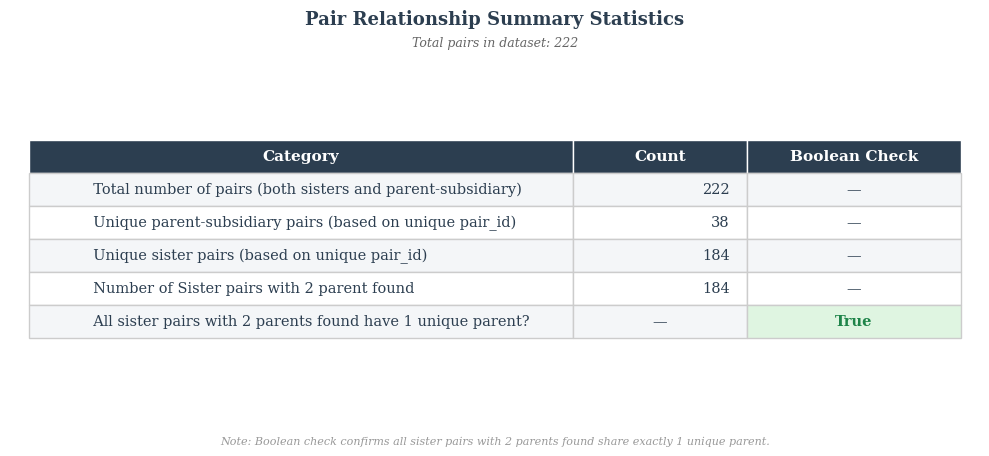

In [128]:
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

fig, ax = plt.subplots(figsize = (10, len(df_t2) * 0.55 + 1.8))
ax.axis('off')


def fmt(val):
    if val is None or (isinstance(val, float) and pd.isna(val)) or str(val).strip() == '':
        return '—'
    return str(val)


col_labels = ['Category', 'Count', 'Boolean Check']
cell_data = [[fmt(row['Category']), fmt(row['Count']), fmt(row['BOOL'])]
             for _, row in df_t2.iterrows()]

table = ax.table(
        cellText = cell_data,
        colLabels = col_labels,
        cellLoc = 'center',
        colWidths = [0.56, 0.18, 0.22],
        loc = 'center'
)

table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 1.9)

# --- Style header ---
header_color = '#2C3E50'
for j in range(len(col_labels)):
    cell = table[(0, j)]
    cell.set_facecolor(header_color)
    cell.set_text_props(weight = 'bold', color = 'white', fontsize = 11)
    cell.set_edgecolor('white')

# --- Style data rows ---
row_colors = ['#FFFFFF', '#F4F6F8']
for i in range(1, len(cell_data) + 1):
    for j in range(len(col_labels)):
        cell = table[(i, j)]
        bg = row_colors[i % 2]
        cell.set_facecolor(bg)
        cell.set_edgecolor('#CCCCCC')

        val = cell_data[i - 1][j]

        if j == 2 and val == 'True':
            cell.set_facecolor('#DFF5E1')
            cell.set_text_props(color = '#1E8449', weight = 'bold', fontsize = 10.5)
        elif j == 2 and val == 'False':
            cell.set_facecolor('#FDECEA')
            cell.set_text_props(color = '#C0392B', weight = 'bold', fontsize = 10.5)
        elif j == 1 and val != '—':
            cell.set_text_props(color = '#2C3E50', ha = 'right')
        else:
            cell.set_text_props(color = '#2C3E50')

# Left-align Category column
for i in range(1, len(cell_data) + 1):
    table[(i, 0)].set_text_props(ha = 'left')
    table[(i, 0)].get_text().set_text('  ' + cell_data[i - 1][0])

# --- Title ---
fig.text(
        0.5, 0.97,
        'Pair Relationship Summary Statistics',
        ha = 'center', va = 'top',
        fontsize = 13, fontweight = 'bold', color = '#2C3E50',
        fontfamily = 'serif'
)
fig.text(
        0.5, 0.91,
        f'Total pairs in dataset: {df_t2["Count"].iloc[0]:,}',
        ha = 'center', va = 'top',
        fontsize = 9, color = '#666666', style = 'italic',
        fontfamily = 'serif'
)

# --- Bottom note ---
fig.text(
        0.5, 0.01,
        'Note: Boolean check confirms all sister pairs with 2 parents found share exactly 1 unique parent.',
        ha = 'center', va = 'bottom',
        fontsize = 8, color = '#999999', style = 'italic',
        fontfamily = 'serif'
)

plt.tight_layout(rect = [0, 0.03, 1, 0.90])

# --- Save as SVG ---
output_path = fi.sp100_30__t2  # adjust path if needed
plt.savefig(output_path, format = 'svg', bbox_inches = 'tight', dpi = 300)
print(f"\n✓ Table saved to: {output_path}")

plt.show()

## PARENTS TYPE - SISTER PAIRS ONLY

### EntityAffiliateRelation.Industry_par

In [157]:
# df05 contains sisters only with both parent found and unique same parent for each pair
df = df05.copy()
print(len(df))

# I need only unique parents IDs
df = df.drop_duplicates(subset = f'{v.affiliate_id__pb}_par', keep = 'first')
print(len(df))  # number of unique parents found for nice sister pairs
df

368
58


,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,...,Location_par,YearFounded_par,AffiliateType_par,HQCity_par,HQState_Province_par,HQCountry_par,LastUpdated_par,pair_parent_count,pair_uniq_parent_count,both_sisters_have_same_parent
2,1,62802-10,57221-29,Bank Austria TFV,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,...,"London, United Kingdom",1945.0,Parent,London,England,United Kingdom,01/30/2023,2,1.0,True
14,11,55440-55,62517-16,Allegheny Health Network,Hospitals/Inpatient Services,"Pittsburgh, PA",1999.0,Sister,Pittsburgh,Pennsylvania,...,"Pittsburgh, PA",1996.0,Parent,Pittsburgh,Pennsylvania,United States,01/30/2023,2,1.0,True
16,12,183796-03,55472-23,Health Insight Capital,Corporate Venture Capital,"Nashville, TN",NaN,Sister,Nashville,Tennessee,...,"Nashville, TN",1968.0,Parent,Nashville,Tennessee,United States,01/30/2023,2,1.0,True
46,27,507359-44,55388-71,Baxter Ventures,Corporate Venture Capital,"Deerfield, IL",2011.0,Sister,Deerfield,Illinois,...,"Deerfield, IL",1931.0,Parent,Deerfield,Illinois,United States,01/30/2023,2,1.0,True
54,31,266395-51,52589-98,Daiwa Corporate Investment,Venture Capital,"Tokyo, Japan",2013.0,Sister,Tokyo,NaN,...,"Tokyo, Japan",1943.0,Parent,Tokyo,None,Japan,05/06/2023,2,1.0,True
56,32,123845-59,52771-15,3M Ventures,Corporate Venture Capital,"Saint Paul, MN",NaN,Sister,Saint Paul,Minnesota,...,"Saint Paul, MN",1902.0,Parent,Saint Paul,Minnesota,United States,01/30/2023,2,1.0,True
64,38,521522-20,185908-06,Bionique Testing Laboratories,Laboratory Services (Healthcare),"Saranac Lake, NY",1990.0,Sister,Saranac Lake,New York,...,"Tokyo, Japan",1931.0,Parent,Tokyo,None,Japan,03/14/2023,2,1.0,True
66,39,521701-84,123725-62,Providence Tarzana Medical Center,Hospitals/Inpatient Services,"Tarzana, CA",1973.0,Sister,Tarzana,California,...,"Vancouver, Canada",1997.0,Parent,Vancouver,British Columbia,Canada,05/06/2023,2,1.0,True
78,47,500764-51,233900-47,UL Ventures,Corporate Venture Capital,"Northbrook, IL",2017.0,Sister,Northbrook,Illinois,...,"Northbrook, IL",1894.0,Parent,Northbrook,Illinois,United States,05/06/2023,2,1.0,True
80,48,233163-19,470772-73,Evernorth Health,Other Healthcare Services,"Saint Louis, MO",2020.0,Sister,Saint Louis,Missouri,...,"Bloomfield, CT",1981.0,Parent,Bloomfield,Connecticut,United States,05/06/2023,2,1.0,True



✓ Figure saved to: /sharedata/camm/c_projects/i100_g7__VC_arms/g32_results_plot_with_tables/sp100_32.svg


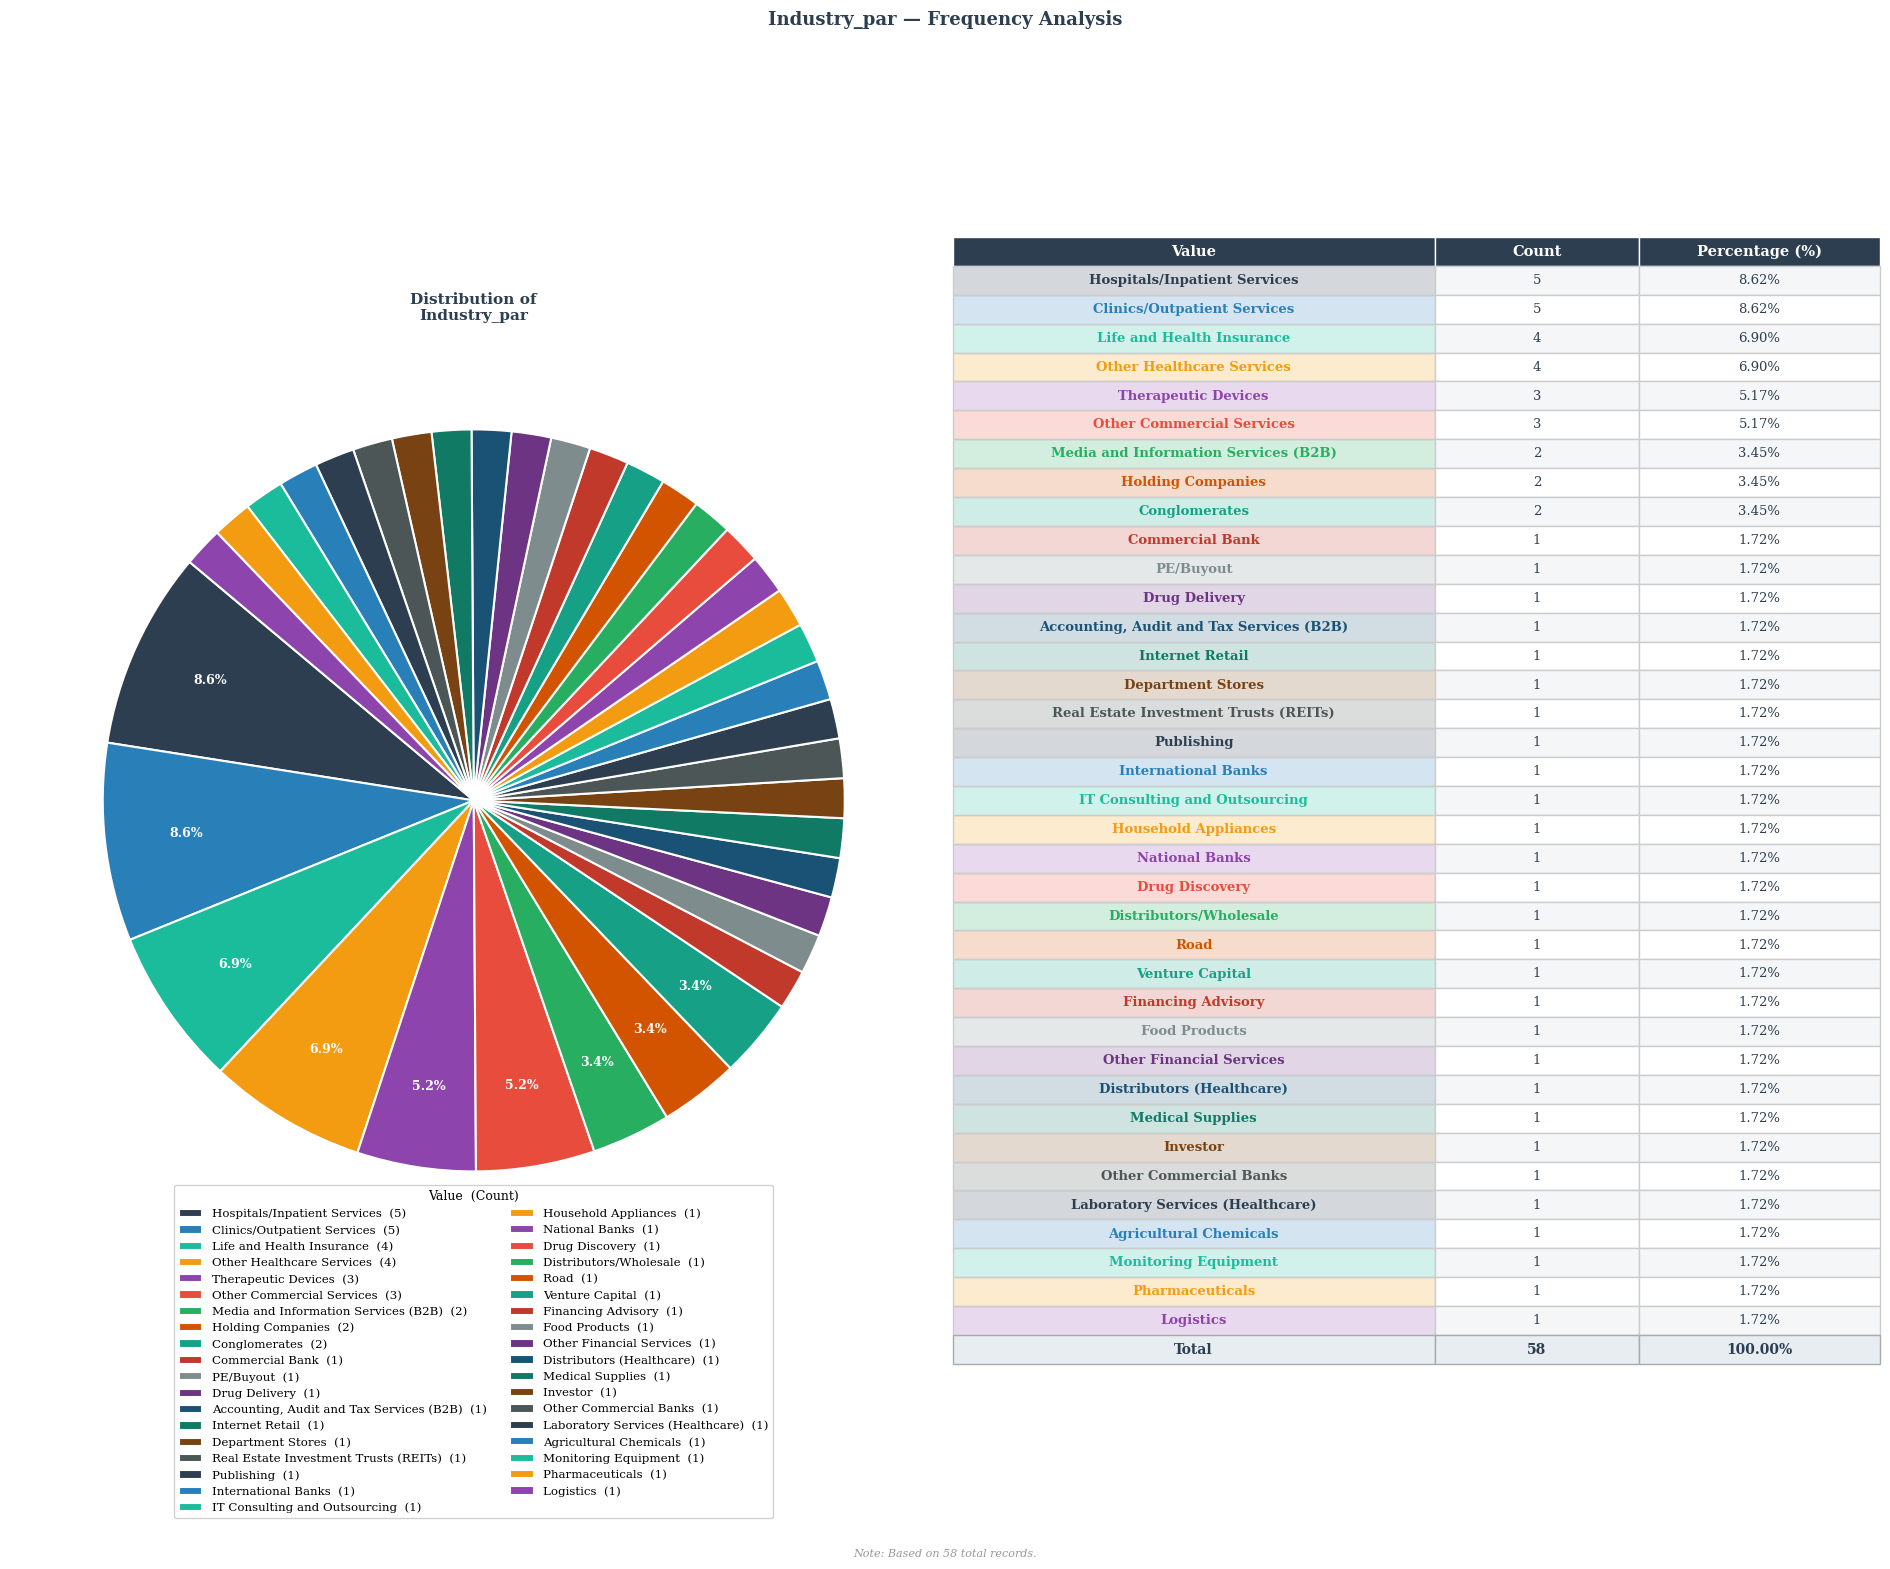

In [161]:
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

# --- Column ---
col = v.industry__pb + '_par'

# --- Compute frequency table ---
counts = df[col].value_counts(dropna = False)
total = counts.sum()
pct = (counts / total * 100).round(2)

freq_df = pd.DataFrame({
        'Value'     : counts.index,
        'Count'     : counts.values,
        'Percentage': pct.values
})

# --- Color palette ---
base_palette = [
        '#2C3E50', '#2980B9', '#1ABC9C', '#F39C12',
        '#8E44AD', '#E74C3C', '#27AE60', '#D35400',
        '#16A085', '#C0392B', '#7F8C8D', '#6C3483',
        '#1A5276', '#117A65', '#784212', '#4D5656'
]
colors = list(itertools.islice(itertools.cycle(base_palette), len(freq_df)))

# --- Layout: row height capped so tall tables don't balloon ---
row_h = 0.35  # ← reduced from 0.55
fig_h = max(8.0, min(len(freq_df) * row_h + 3.0, 20.0))  # ← hard cap at 20 inches

fig, (ax_pie, ax_tbl) = plt.subplots(
        1, 2,
        figsize = (19, fig_h),
        gridspec_kw = {'width_ratios': [1.1, 1.1]}
)

# ── Pie chart ──────────────────────────────────────────────
wedges, texts, autotexts = ax_pie.pie(
        freq_df['Count'],
        labels = None,
        autopct = lambda p: f'{p:.1f}%' if p > 3 else '',
        startangle = 140,
        colors = colors,
        wedgeprops = {'edgecolor': 'white', 'linewidth': 1.5},
        pctdistance = 0.78
)

for at in autotexts:
    at.set_fontsize(9)
    at.set_color('white')
    at.set_fontweight('bold')

ax_pie.legend(
        wedges,
        [f"{v}  ({c:,})" for v, c in zip(freq_df['Value'], freq_df['Count'])],
        title = 'Value  (Count)',
        title_fontsize = 9,
        fontsize = 8.5,
        loc = 'lower center',
        bbox_to_anchor = (0.5, -0.28),
        frameon = True,
        framealpha = 0.9,
        ncol = 2
)

ax_pie.set_title(f'Distribution of\n{col}', fontsize = 11,
                 fontweight = 'bold', color = '#2C3E50', pad = 12)

# ── Frequency table ────────────────────────────────────────
ax_tbl.axis('off')

col_labels = ['Value', 'Count', 'Percentage (%)']
cell_data = [
        [str(row['Value']), f"{row['Count']:,}", f"{row['Percentage']:.2f}%"]
        for _, row in freq_df.iterrows()
]
cell_data.append(['Total', f"{total:,}", '100.00%'])

table = ax_tbl.table(
        cellText = cell_data,
        colLabels = col_labels,
        cellLoc = 'center',
        colWidths = [0.52, 0.22, 0.26],
        loc = 'center'
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.5)  # ← reduced from 1.85 to compress row height in table

# Header
header_color = '#2C3E50'
for j in range(3):
    cell = table[(0, j)]
    cell.set_facecolor(header_color)
    cell.set_text_props(weight = 'bold', color = 'white', fontsize = 10.5)
    cell.set_edgecolor('white')

# Data rows
row_colors = ['#FFFFFF', '#F4F6F8']

for i in range(1, len(cell_data) + 1):
    is_total = (i == len(cell_data))
    for j in range(3):
        cell = table[(i, j)]
        cell.set_edgecolor('#CCCCCC')

        if is_total:
            cell.set_facecolor('#E8EDF2')
            cell.set_text_props(weight = 'bold', color = '#2C3E50', fontsize = 10)
            cell.set_edgecolor('#AAAAAA')
        else:
            cell.set_facecolor(row_colors[i % 2])
            if j == 0:
                cell.set_facecolor(colors[i - 1] + '33')
                cell.set_text_props(color = colors[i - 1], weight = 'bold', fontsize = 9.5)
            else:
                cell.set_text_props(color = '#2C3E50')

# --- Titles & notes ---
fig.suptitle(
        f'{col} — Frequency Analysis',
        fontsize = 13, fontweight = 'bold', color = '#2C3E50',
        y = 0.98, fontfamily = 'serif'  # ← pulled down closer to content
)
fig.text(
        0.5, 0.01,  # ← raised slightly from -0.01
        f'Note: Based on {total:,} total records.',
        ha = 'center', fontsize = 8, color = '#999999', style = 'italic', fontfamily = 'serif'
)

plt.tight_layout(rect = [0, 0.03, 1, 0.96])  # ← rect clips excess whitespace

output_path = fi.sp100_32
plt.savefig(output_path, format = 'svg', bbox_inches = 'tight', dpi = 300)
print(f"\n✓ Figure saved to: {output_path}")

plt.show()

In [159]:
df_comps = pd.read_parquet(file.pb_companies__parq)
df_comps

,CompanyID,CompanyName,CompanyAlsoKnownAs,CompanyFormerName,CompanyLegalName,Description,Keywords,CompanyFinancingStatus,CompanyFinancingStatusDate,TotalRaised,...,LastFinancingDebtSize,LastFinancingDebtDate,LastFinancingStatus,LastInvestmentInvestorOwnership,FacebookProfileURL,TwitterProfileURL,LinkedInProfileURL,PitchBookProfileLink,MorningstarID,LastUpdated
0,10010-89,Broadcom (Acquired 2016),None,None,Broadcom Corp.,Manufacturer of semiconductors. The company de...,"ethernet communication, fabless semiconductor,...",Formerly VC-backed,02/01/2016,66.360000,...,15600.0,02/01/2016,Completed,NaN,None,None,None,https://my.pitchbook.com?c=10010-89,0C00000711,01/30/2023
1,187998-49,Matador Film,None,None,None,Operator of media production company. The comp...,"media production, scriptwriting, tv series pro...",Corporate Backed or Acquired,08/29/2017,NaN,...,NaN,08/29/2017,Completed,NaN,None,None,None,https://my.pitchbook.com?c=187998-49,None,05/06/2023
2,10011-16,Acetex,None,None,Acetex Corporation,"Manufacturer of acetic acid in Vancouver, Cana...","acetic acid, acid derivative, pharmaceutical",Corporate Backed or Acquired,07/20/2005,4.247384,...,NaN,07/20/2005,Completed,NaN,None,None,https://www.linkedin.com/company/8322399,https://my.pitchbook.com?c=10011-16,None,04/26/2023
3,187998-58,Chronicle Studio,None,None,None,Provider of web development services intended ...,"web application developer, web developer's pla...",Accelerator/Incubator Backed,None,0.050000,...,NaN,None,Completed,NaN,https://www.facebook.com/TeamChronicle,https://twitter.com/teamchronicle,https://www.linkedin.com/company/chronicle-studio,https://my.pitchbook.com?c=187998-58,None,01/30/2023
4,10011-43,Basic Energy Services,Basic,Sierra Well Service,Basic Energy Services Inc,Basic Energy Services Inc is a provider of wel...,"contract drilling, water logistics, water logi...",Formerly PE-Backed,10/01/2021,50.000000,...,NaN,10/01/2021,Completed,NaN,None,None,None,https://my.pitchbook.com?c=10011-43,0C000006UZ,01/30/2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
952979,12394-90,"Martin, Shudt, Wallace, DiLorenzo & Johnson",None,None,None,Provider of legal services catering to corpora...,"law firm, legal firm operator, legal service, ...",Corporate Backed or Acquired,10/01/2021,NaN,...,NaN,10/01/2021,Completed,NaN,None,None,None,https://my.pitchbook.com?c=12394-90,None,01/30/2023
952980,11705-23,3DGeo Development,3DGeo,None,"3DGeo Development, Inc.",Provider of advanced seismic imaging software ...,"seismic imaging, seismic inversion, spectral i...",Formerly PE-Backed,11/03/2008,NaN,...,NaN,11/03/2008,Completed,NaN,None,None,None,https://my.pitchbook.com?c=11705-23,None,01/30/2023
952981,390019-51,Cooper Glass Company,None,None,Cooper Glass Company LLC,Provider of residential and commercial glass s...,"commercial glass product, commercial glass ser...",Corporate Backed or Acquired,02/20/2020,NaN,...,NaN,02/20/2020,Completed,NaN,https://www.facebook.com/Cooper-Glass-Company-...,None,https://www.linkedin.com/company/cooper-glass-...,https://my.pitchbook.com?c=390019-51,None,05/06/2023
952982,12230-92,Pinnacle Electronics,None,"Contraves, Contraves Goerz Corporation",Pinnacle Electronics LLC,Manufacturer of high-reliability electronic as...,"cable, circuit, circuit assembly, electromecha...",Formerly PE-Backed,01/22/2016,NaN,...,NaN,01/22/2016,Completed,NaN,None,None,None,https://my.pitchbook.com?c=12230-92,None,01/30/2023


In [160]:
mks = df_comps[v.company_id].isin(df05[f'{var.affiliate_id}_par'])
df_comps_par = df_comps[mks]
print(len(df_comps_par))

47


In [133]:
df_comps_par_1 = df_comps_par.drop_duplicates(subset = v.company_id, keep = 'first')
print(len(df_comps_par_1))  # should be the same as df_comps_par if there is no duplicate company ID

47


In [162]:
df_comps_par = df_comps_par_1.copy()

In [163]:
df_comps_par

,CompanyID,CompanyName,CompanyAlsoKnownAs,CompanyFormerName,CompanyLegalName,Description,Keywords,CompanyFinancingStatus,CompanyFinancingStatusDate,TotalRaised,...,LastFinancingDebtSize,LastFinancingDebtDate,LastFinancingStatus,LastInvestmentInvestorOwnership,FacebookProfileURL,TwitterProfileURL,LinkedInProfileURL,PitchBookProfileLink,MorningstarID,LastUpdated
1542,10326-34,Walgreens Boots Alliance,WBA,None,"Walgreens Boots Alliance, Inc.",Walgreens Boots Alliance is one of the largest...,"pharmaceutical wholesale, pharmacy store chain...",Corporation,11/03/2016,18877.329000,...,NaN,11/03/2016,Completed,NaN,https://www.facebook.com/WalgreensBootsAllianc...,https://twitter.com/WBA_Global,https://www.linkedin.com/company/walgreens-boo...,https://my.pitchbook.com?c=10326-34,0C000009KY,05/18/2023
2148,10441-90,HCA Management Services,HCA,None,"HCA Management Services, L.P.",HCA Healthcare is a Nashville-based healthcare...,"diagnostic center, imaging center, surgery center",Formerly PE-Backed,03/01/2016,10030.856408,...,1000.000000,03/01/2016,Completed,NaN,https://www.facebook.com/HCACare,https://twitter.com/HCAhealthcare,https://www.linkedin.com/company/hca,https://my.pitchbook.com?c=10441-90,0C00000B85,04/26/2023
3020,10574-74,Baxter International,Baxter,Don Baxter Intravenous Products Corporation,"Baxter International, Inc.",Baxter offers a variety of medical instruments...,"contract manufacturing, healthcare, healthcare...",Corporation,06/01/2017,2000.000000,...,NaN,06/01/2017,Completed,NaN,https://www.facebook.com/baxterinternationalinc,https://twitter.com/baxter_intl,https://www.linkedin.com/company/baxter-health...,https://my.pitchbook.com?c=10574-74,0C000006V2,04/28/2023
7200,11502-91,Danone,The Danone,None,Danone S.A.,"Following the acquisition of WhiteWave, Danone...","dairy product, dairy production, dairy product...",Corporation,04/20/2022,1458.981002,...,NaN,04/20/2022,Failed/Cancelled,NaN,https://www.facebook.com/danone,https://twitter.com/Danone,https://www.linkedin.com/company/danone,https://my.pitchbook.com?c=11502-91,0C00000B5G,04/25/2023
7642,10831-42,McKesson,None,None,McKesson Corp,McKesson Corp is one of three leading pharmace...,"biopharma company, diagnostic imaging, health ...",Corporation,12/30/1987,NaN,...,NaN,12/30/1987,Completed,NaN,https://www.facebook.com/McKessonCorporation,https://twitter.com/McKesson,https://www.linkedin.com/company/mckesson,https://my.pitchbook.com?c=10831-42,0C000008A9,05/17/2023
12416,11215-09,3i Group,3i,Industrial and Commercial Financial Corporation,3i Group plc,3i Group PLC is a closed-ended investment fund...,"investment service, private equity",Formerly PE-Backed,07/18/1994,NaN,...,NaN,07/18/1994,Completed,NaN,https://www.facebook.com/3iplc,https://twitter.com/3iplc,https://www.linkedin.com/company/3i-group-plc,https://my.pitchbook.com?c=11215-09,0C00000Q5R,05/18/2023
12944,11521-81,Air Liquide,None,None,L'Air Liquide S.A.,"Founded in 1902, Air Liquide is one of the lea...","industrial gas, industrial gas product, indust...",Corporation,11/09/2020,NaN,...,NaN,11/09/2020,Completed,NaN,https://www.facebook.com/AirLiquide,https://twitter.com/AirLiquideGroup,https://www.linkedin.com/company/airliquide,https://my.pitchbook.com?c=11521-81,0C00000VWI,04/10/2023
14100,10663-66,3M,MMM,Minnesota Mining and Manufacturing Company,The 3M Company,3M is a multinational conglomerate that has op...,"abrasives, adhesives, lighting management, mic...",Corporation,01/14/1946,NaN,...,NaN,01/14/1946,Completed,NaN,None,https://twitter.com/3M,None,https://my.pitchbook.com?c=10663-66,0C0000095Q,04/26/2023
15672,11242-00,Medtronic,"MDT, Medtronic Cardiovascular Asia Pacific",None,Medtronic plc,"One of the largest medical-device companies, M...","chronic disease, chronic pain relief, chronic ...",Corporation,05/02/1973,NaN,...,NaN,05/02/1973,Completed,NaN,https://www.facebook.com/Medtronic,https://twitter.com/Medtronic,https://www.linkedin.com/company/medtronic,https://my.pitchbook.com?c=11242-00,0

### Universe


✓ Figure saved to: /sharedata/camm/c_projects/i100_g7__VC_arms/g32_results_plot_with_tables/sp100_35.svg


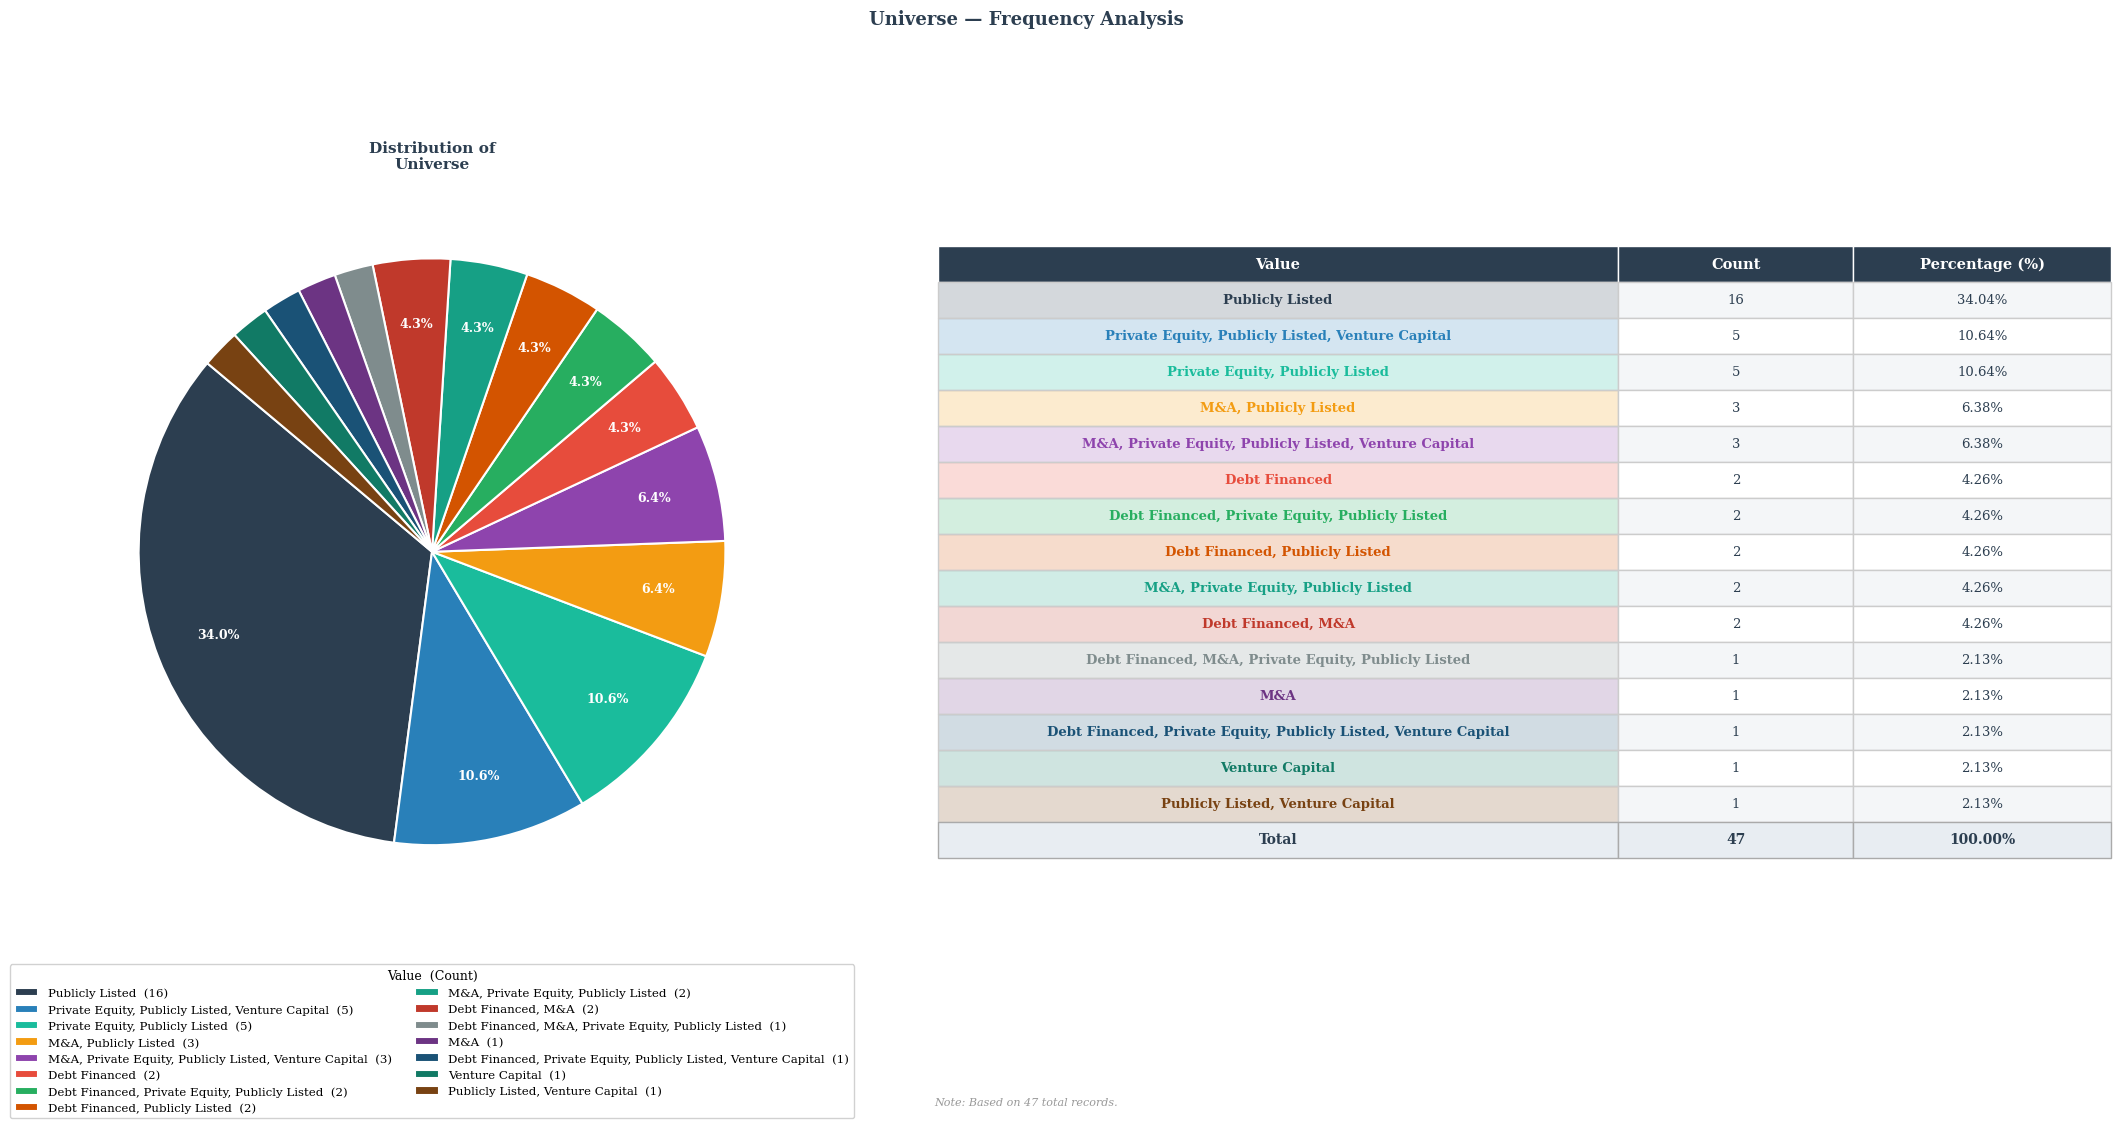

In [164]:
df = df_comps_par.copy()

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

# --- Column ---
col = v.universe__pb

# --- Compute frequency table ---
counts = df[col].value_counts(dropna = False)
total = counts.sum()
pct = (counts / total * 100).round(2)

freq_df = pd.DataFrame({
        'Value'     : counts.index,
        'Count'     : counts.values,
        'Percentage': pct.values
})

# --- Color palette ---
base_palette = [
        '#2C3E50', '#2980B9', '#1ABC9C', '#F39C12',
        '#8E44AD', '#E74C3C', '#27AE60', '#D35400',
        '#16A085', '#C0392B', '#7F8C8D', '#6C3483',
        '#1A5276', '#117A65', '#784212', '#4D5656'
]
colors = list(itertools.islice(itertools.cycle(base_palette), len(freq_df)))

# --- Layout ---
fig, (ax_pie, ax_tbl) = plt.subplots(
        1, 2,
        figsize = (22, max(6.0, len(freq_df) * 0.55 + 2.5)),  # ← wider figure
        gridspec_kw = {'width_ratios': [1.0, 1.6]}  # ← more space for table
)

# ── Pie chart ──────────────────────────────────────────────
wedges, texts, autotexts = ax_pie.pie(
        freq_df['Count'],
        labels = None,
        autopct = lambda p: f'{p:.1f}%' if p > 3 else '',
        startangle = 140,
        colors = colors,
        wedgeprops = {'edgecolor': 'white', 'linewidth': 1.5},
        pctdistance = 0.78
)

for at in autotexts:
    at.set_fontsize(9)
    at.set_color('white')
    at.set_fontweight('bold')

ax_pie.legend(
        wedges,
        [f"{v}  ({c:,})" for v, c in zip(freq_df['Value'], freq_df['Count'])],
        title = 'Value  (Count)',
        title_fontsize = 9,
        fontsize = 8.5,
        loc = 'lower center',
        bbox_to_anchor = (0.5, -0.28),
        frameon = True,
        framealpha = 0.9,
        ncol = 2
)

ax_pie.set_title(f'Distribution of\n{col}', fontsize = 11,
                 fontweight = 'bold', color = '#2C3E50', pad = 12)

# ── Frequency table ────────────────────────────────────────
ax_tbl.axis('off')

col_labels = ['Value', 'Count', 'Percentage (%)']
cell_data = [
        [str(row['Value']), f"{row['Count']:,}", f"{row['Percentage']:.2f}%"]
        for _, row in freq_df.iterrows()
]
cell_data.append(['Total', f"{total:,}", '100.00%'])

table = ax_tbl.table(
        cellText = cell_data,
        colLabels = col_labels,
        cellLoc = 'center',
        colWidths = [0.58, 0.20, 0.22],  # ← wider Value, tighter Count/Pct
        loc = 'center'
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.85)

# Header
header_color = '#2C3E50'
for j in range(3):
    cell = table[(0, j)]
    cell.set_facecolor(header_color)
    cell.set_text_props(weight = 'bold', color = 'white', fontsize = 10.5)
    cell.set_edgecolor('white')

# Data rows
row_colors = ['#FFFFFF', '#F4F6F8']

for i in range(1, len(cell_data) + 1):
    is_total = (i == len(cell_data))
    for j in range(3):
        cell = table[(i, j)]
        cell.set_edgecolor('#CCCCCC')

        if is_total:
            cell.set_facecolor('#E8EDF2')
            cell.set_text_props(weight = 'bold', color = '#2C3E50', fontsize = 10)
            cell.set_edgecolor('#AAAAAA')
        else:
            cell.set_facecolor(row_colors[i % 2])
            if j == 0:
                cell.set_facecolor(colors[i - 1] + '33')
                cell.set_text_props(color = colors[i - 1], weight = 'bold', fontsize = 9.5)
            else:
                cell.set_text_props(color = '#2C3E50')

# --- Titles & notes ---
fig.suptitle(
        f'{col} — Frequency Analysis',
        fontsize = 13, fontweight = 'bold', color = '#2C3E50',
        y = 1.01, fontfamily = 'serif'
)
fig.text(
        0.5, -0.01,
        f'Note: Based on {total:,} total records.',
        ha = 'center', fontsize = 8, color = '#999999', style = 'italic', fontfamily = 'serif'
)

plt.tight_layout()

output_path = fi.sp100_35
plt.savefig(output_path, format = 'svg', bbox_inches = 'tight', dpi = 300)
print(f"\n✓ Figure saved to: {output_path}")

plt.show()

### PrimaryIndustrySector


✓ Figure saved to: /sharedata/camm/c_projects/i100_g7__VC_arms/g32_results_plot_with_tables/sp100_40.svg


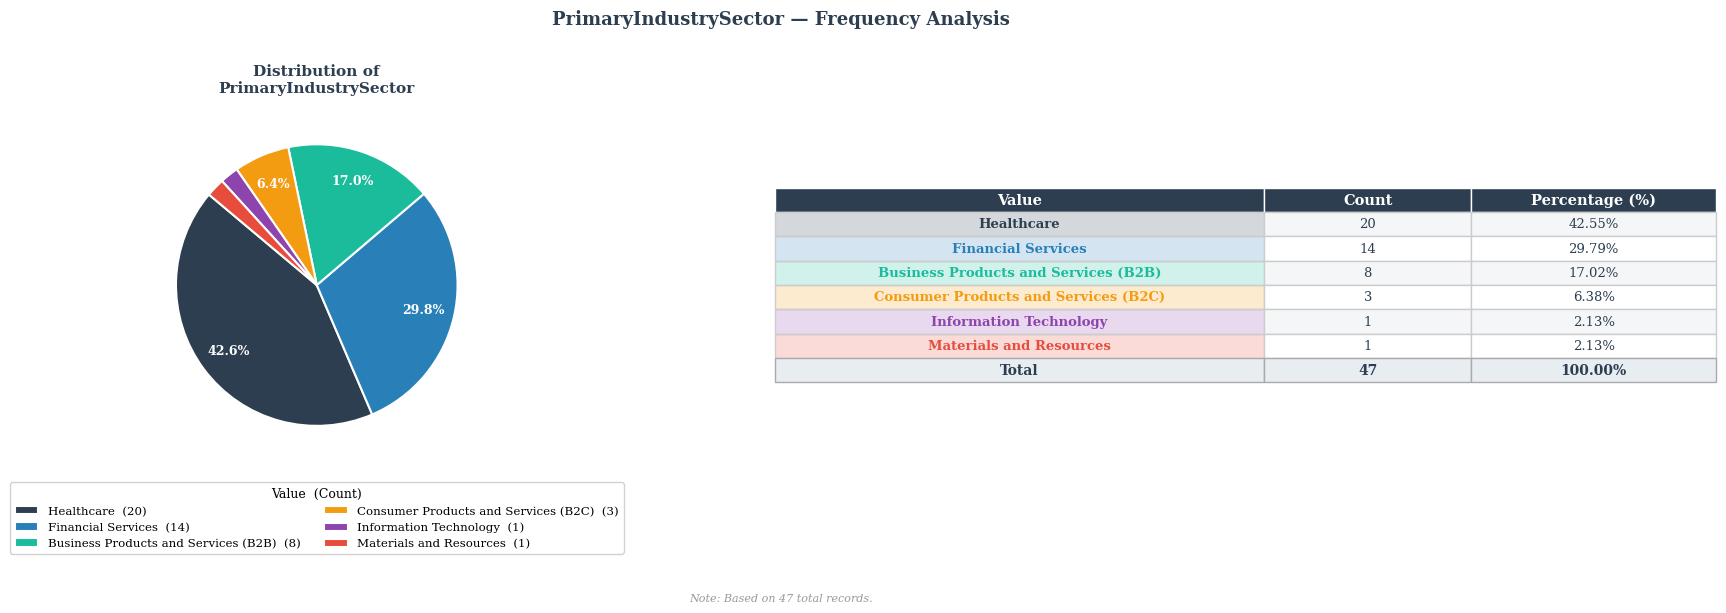

In [165]:
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

# --- Column ---
col = v.primary_industry_sec__pb

# --- Compute frequency table ---
counts = df[col].value_counts(dropna = False)
total = counts.sum()
pct = (counts / total * 100).round(2)

freq_df = pd.DataFrame({
        'Value'     : counts.index,
        'Count'     : counts.values,
        'Percentage': pct.values
})

# --- Color palette ---
base_palette = [
        '#2C3E50', '#2980B9', '#1ABC9C', '#F39C12',
        '#8E44AD', '#E74C3C', '#27AE60', '#D35400',
        '#16A085', '#C0392B', '#7F8C8D', '#6C3483',
        '#1A5276', '#117A65', '#784212', '#4D5656'
]
colors = list(itertools.islice(itertools.cycle(base_palette), len(freq_df)))

# --- Layout ---
fig, (ax_pie, ax_tbl) = plt.subplots(
        1, 2,
        figsize = (19, max(5.0, len(freq_df) * 0.55 + 2.5)),  # ← between 16 and 22
        gridspec_kw = {'width_ratios': [1.1, 1.1]}  # ← balanced equal halves
)

# ── Pie chart ──────────────────────────────────────────────
wedges, texts, autotexts = ax_pie.pie(
        freq_df['Count'],
        labels = None,
        autopct = lambda p: f'{p:.1f}%' if p > 3 else '',
        startangle = 140,
        colors = colors,
        wedgeprops = {'edgecolor': 'white', 'linewidth': 1.5},
        pctdistance = 0.78
)

for at in autotexts:
    at.set_fontsize(9)
    at.set_color('white')
    at.set_fontweight('bold')

ax_pie.legend(
        wedges,
        [f"{v}  ({c:,})" for v, c in zip(freq_df['Value'], freq_df['Count'])],
        title = 'Value  (Count)',
        title_fontsize = 9,
        fontsize = 8.5,
        loc = 'lower center',
        bbox_to_anchor = (0.5, -0.28),
        frameon = True,
        framealpha = 0.9,
        ncol = 2
)

ax_pie.set_title(f'Distribution of\n{col}', fontsize = 11,
                 fontweight = 'bold', color = '#2C3E50', pad = 12)

# ── Frequency table ────────────────────────────────────────
ax_tbl.axis('off')

col_labels = ['Value', 'Count', 'Percentage (%)']
cell_data = [
        [str(row['Value']), f"{row['Count']:,}", f"{row['Percentage']:.2f}%"]
        for _, row in freq_df.iterrows()
]
cell_data.append(['Total', f"{total:,}", '100.00%'])

table = ax_tbl.table(
        cellText = cell_data,
        colLabels = col_labels,
        cellLoc = 'center',
        colWidths = [0.52, 0.22, 0.26],  # ← wider Value to avoid truncation
        loc = 'center'
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.85)

# Header
header_color = '#2C3E50'
for j in range(3):
    cell = table[(0, j)]
    cell.set_facecolor(header_color)
    cell.set_text_props(weight = 'bold', color = 'white', fontsize = 10.5)
    cell.set_edgecolor('white')

# Data rows
row_colors = ['#FFFFFF', '#F4F6F8']

for i in range(1, len(cell_data) + 1):
    is_total = (i == len(cell_data))
    for j in range(3):
        cell = table[(i, j)]
        cell.set_edgecolor('#CCCCCC')

        if is_total:
            cell.set_facecolor('#E8EDF2')
            cell.set_text_props(weight = 'bold', color = '#2C3E50', fontsize = 10)
            cell.set_edgecolor('#AAAAAA')
        else:
            cell.set_facecolor(row_colors[i % 2])
            if j == 0:
                cell.set_facecolor(colors[i - 1] + '33')
                cell.set_text_props(color = colors[i - 1], weight = 'bold', fontsize = 9.5)
            else:
                cell.set_text_props(color = '#2C3E50')

# --- Titles & notes ---
fig.suptitle(
        f'{col} — Frequency Analysis',
        fontsize = 13, fontweight = 'bold', color = '#2C3E50',
        y = 1.01, fontfamily = 'serif'
)
fig.text(
        0.5, -0.01,
        f'Note: Based on {total:,} total records.',
        ha = 'center', fontsize = 8, color = '#999999', style = 'italic', fontfamily = 'serif'
)

plt.tight_layout()

output_path = fi.sp100_40
plt.savefig(output_path, format = 'svg', bbox_inches = 'tight', dpi = 300)
print(f"\n✓ Figure saved to: {output_path}")

plt.show()

## VCs FROM BOTH PAIRS
VC data from BOTH SISTER PAIRS AND PARENT-SUBSIDIARY PAIRS

In [167]:
# Now I only want VCs with parent hospital from both sister and parent-subsidiary groups
# Then I want their count
# Then I want to plot the distribution of their industry and primary industry sector and universe for both hospitals and VCs

In [176]:
# How I defined hospitals previously?

vc_industries = {
        0: 'Corporate Venture Capital',
        1: 'Venture Capital',
        2: 'Not-For-Profit Venture Capital',
}

hospital_industries = {
        0: 'Clinics/Outpatient Services',
        1: 'Hospitals/Inpatient Services',
        2: 'Elder and Disabled Care',
        3: 'Laboratory Services (Healthcare)',
        4: 'Other Healthcare Services',
}

In [177]:
df10

,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,...,Location_par,YearFounded_par,AffiliateType_par,HQCity_par,HQState_Province_par,HQCountry_par,LastUpdated_par,pair_parent_count,pair_uniq_parent_count,both_sisters_have_same_parent
369,0,166514-86,434783-53,Ballad Ventures,Corporate Venture Capital,"Johnson City, TN",2020.0,Subsidiary,Johnson City,Tennessee,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,1,62802-10,57221-29,Bank Austria TFV,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,...,"London, United Kingdom",1945.0,Parent,London,England,United Kingdom,01/30/2023,2.0,1.0,True
1,1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,...,"London, United Kingdom",1945.0,Parent,London,England,United Kingdom,01/30/2023,2.0,1.0,True
370,2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,247,435249-19,435253-51,Novamind,Venture Capital,"Toronto, Canada",2019.0,Parent,Toronto,Ontario,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
441,249,164588-68,507452-14,Wanyuandia Investment,Corporate Venture Capital,"Hangzhou, China",2021.0,Subsidiary,Hangzhou,Zhejiang,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
440,249,507452-14,164588-68,NaN,NaN,NaN,NaN,Parent,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
443,253,166341-79,157276-27,Ora Clinical,Other Healthcare Services,"Andover, MA",1985.0,Parent,Andover,Massachusetts,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [186]:
# Add affiliate parent type column to df10
# To indicate whether it is a VC or hospital or none of them

df11 = df10.copy()

msk_0 = df11[f'{v.affiliate_id__pb}_par'].notna()  # those rows with parent found == nice pairs

df11[v.aff_type_par] = np.nan  # initialize the column with NaN
df11.loc[msk_0, v.aff_type_par] = c.not_vc_nor_hospital  # default to not VC nor hospital

msk_1 = msk & df11[f'{v.industry__pb}_par'].isin(vc_industries.values())

df11.loc[msk_1, v.aff_type_par] = c.vc

print(msk_1.sum())  # those nice pairs with parent in VC industry


2


In [187]:
msk_2 = msk_0 & df11[f'{v.industry__pb}_par'].isin(hospital_industries.values())

df11.loc[msk_2, v.aff_type_par] = c.hospital

print(msk_2.sum())  # those nice pairs with parent in hospital industry


162


In [198]:
df11.to_excel(fi.sp100_45_df11, index = False)
df11

,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,...,YearFounded_par,AffiliateType_par,HQCity_par,HQState_Province_par,HQCountry_par,LastUpdated_par,pair_parent_count,pair_uniq_parent_count,both_sisters_have_same_parent,affiliate_type_par
369,0,166514-86,434783-53,Ballad Ventures,Corporate Venture Capital,"Johnson City, TN",2020.0,Subsidiary,Johnson City,Tennessee,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,1,62802-10,57221-29,Bank Austria TFV,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,...,1945.0,Parent,London,England,United Kingdom,01/30/2023,2.0,1.0,True,not_vc_nor_hospital
1,1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,...,1945.0,Parent,London,England,United Kingdom,01/30/2023,2.0,1.0,True,not_vc_nor_hospital
370,2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,247,435249-19,435253-51,Novamind,Venture Capital,"Toronto, Canada",2019.0,Parent,Toronto,Ontario,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
441,249,164588-68,507452-14,Wanyuandia Investment,Corporate Venture Capital,"Hangzhou, China",2021.0,Subsidiary,Hangzhou,Zhejiang,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
440,249,507452-14,164588-68,NaN,NaN,NaN,NaN,Parent,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
443,253,166341-79,157276-27,Ora Clinical,Other Healthcare Services,"Andover, MA",1985.0,Parent,Andover,Massachusetts,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [196]:
# Just to check before going forward, there should not be any new pair by finding the parent of sister pairs

df = df11.copy()

# Build a set of all existing (entity_id, affiliate_id) pairs
existing_pairs = set(zip(df[v.entity_id__pb], df[v.affiliate_id__pb]))

# Filter rows where affiliate_id_par is not NA
has_par = df[df[f'{v.affiliate_id__pb}_par'].notna()].copy()

# Check if (entity_id, affiliate_id_par) exists in the existing pairs
has_par['pair_exists'] = has_par.apply(
        lambda row: (row[v.entity_id__pb], row[v.affiliate_id__pb]) in existing_pairs,
        axis = 1
)

# --- Summary ---
total_checked = len(has_par)
all_found = has_par['pair_exists'].all()
n_missing = (~has_par['pair_exists']).sum()

print(f"Rows with affiliate_id_par not NA : {total_checked:,}")
print(f"All pairs found                   : {all_found}")
print(f"Missing pairs                     : {n_missing:,}")

# --- Show the offending rows if any ---
if not all_found:
    missing = has_par[~has_par['pair_exists']][['entity_id', 'affiliate_id', 'affiliate_id_par']]
    print(f"\n--- Rows where (entity_id, affiliate_id_par) pair NOT found ---")
    display(missing)
else:
    print("\n✓ All (entity_id, affiliate_id_par) pairs are present in (entity_id, affiliate_id).")

Rows with affiliate_id_par not NA : 368
All pairs found                   : True
Missing pairs                     : 0

✓ All (entity_id, affiliate_id_par) pairs are present in (entity_id, affiliate_id).


In [201]:
# now find VCs with hospital parents from both sister and parent-subsidiary pairs

# from par-sub parents

# entity type = vc
# affiliate type = hospital
# AffiliateType = parent -> the hospital is the parent of the VC
# Not in sister pairs (they have common members) -> remove repeated pairs

msk_1 = df11[v.entity_type].eq(c.vc)
msk_1 &= df11[v.affiliate_type].eq(c.hospital)
msk_1 &= df11[v.affiliate_type__pb].eq(c.par)
msk_1 &= ~ df11[v.affiliate_id__pb].isin(
        df11[v.affiliate_id__pb + '_par'])  # ensure the hospital parent is not from sister pairs

df_vc_ps = df11[msk_1]
print(len(df_vc_ps))
df_vc_ps

31


,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,...,YearFounded_par,AffiliateType_par,HQCity_par,HQState_Province_par,HQCountry_par,LastUpdated_par,pair_parent_count,pair_uniq_parent_count,both_sisters_have_same_parent,affiliate_type_par
368,0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
370,2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
373,3,56040-94,56084-95,MemorialCare Health System,Clinics/Outpatient Services,"Long Beach, CA",1907.0,Parent,Long Beach,California,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
375,5,433710-46,50987-17,Mass General Brigham,Hospitals/Inpatient Services,"Boston, MA",1994.0,Parent,Boston,Massachusetts,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
376,6,55757-98,51726-52,Mayo Clinic,Clinics/Outpatient Services,"Rochester, MN",1889.0,Parent,Rochester,Minnesota,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
380,26,149695-84,126530-83,Healthware Group,Other Healthcare Services,"Salerno, Italy",1996.0,Parent,Salerno,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
382,29,432514-09,55280-53,BGI Genomics,Laboratory Services (Healthcare),"Shenzhen, China",1999.0,Parent,Shenzhen,Guangdong,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
385,30,54810-10,54249-85,UNC REX Healthcare,Laboratory Services (Healthcare),"Raleigh, NC",1894.0,Parent,Raleigh,North Carolina,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
388,35,51450-31,150350-41,IU Health La Porte Hospital,Hospitals/Inpatient Services,"La Porte, IN",1972.0,Parent,La Porte,Indiana,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
391,37,521254-27,54999-82,Meinian Onehealth,Clinics/Outpatient Services,"Shanghai, China",2004.0,Parent,Shanghai,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [203]:
# VCs from sister pairs with hospital parent

# conditions
# entity type = vc
# affiliate_type_par = hospital
# AffiliateType_par = parent

# all the repeated items here considered for sister pairs group

msk_2 = df11[v.entity_type].eq(c.vc)
msk_2 &= df11[v.aff_type_par].eq(c.hospital)
msk_2 &= df11[f'{v.affiliate_type__pb}_par'].eq(c.par)

df_vc_sis = df11[msk_2]
print(len(df_vc_sis))
df_vc_sis

81


,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,...,YearFounded_par,AffiliateType_par,HQCity_par,HQState_Province_par,HQCountry_par,LastUpdated_par,pair_parent_count,pair_uniq_parent_count,both_sisters_have_same_parent,affiliate_type_par
5,12,55472-23,183796-03,Highlands Regional Medical Center,Hospitals/Inpatient Services,"Sebring, FL",1965.0,Sister,Sebring,Florida,...,1968.0,Parent,Nashville,Tennessee,United States,01/30/2023,2.0,1.0,True,hospital
6,13,55472-23,227325-97,Silicon Valley Surgery Center,Clinics/Outpatient Services,"Los Gatos, CA",1998.0,Sister,Los Gatos,California,...,1968.0,Parent,Nashville,Tennessee,United States,01/30/2023,2.0,1.0,True,hospital
9,14,55472-23,153697-42,Medical City Frisco,Clinics/Outpatient Services,"Frisco, TX",2010.0,Sister,Frisco,Texas,...,1968.0,Parent,Nashville,Tennessee,United States,01/30/2023,2.0,1.0,True,hospital
10,15,55472-23,151100-02,Memorial Health University Medical Center,Hospitals/Inpatient Services,"Savannah, GA",1955.0,Sister,Savannah,Georgia,...,1968.0,Parent,Nashville,Tennessee,United States,01/30/2023,2.0,1.0,True,hospital
12,16,55472-23,351790-84,Paramount Urgent Care,Clinics/Outpatient Services,"Lady Lake, FL",2008.0,Sister,Lady Lake,Florida,...,1968.0,Parent,Nashville,Tennessee,United States,01/30/2023,2.0,1.0,True,hospital
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,239,435625-48,98729-83,Colorado Springs Health Partners,Clinics/Outpatient Services,"Colorado Springs, CO",1946.0,Sister,Colorado Springs,Colorado,...,1994.0,Parent,Denver,Colorado,United States,05/06/2023,2.0,1.0,True,hospital
361,240,435625-48,236925-46,Oregon Kidney & Hypertension,Clinics/Outpatient Services,"Portland, OR",2006.0,Sister,Portland,Oregon,...,1994.0,Parent,Denver,Colorado,United States,05/06/2023,2.0,1.0,True,hospital
362,241,435625-48,224439-04,Sun Health Dialysis,Clinics/Outpatient Services,"Joliet, IL",1991.0,Sister,Joliet,Illinois,...,1994.0,Parent,Denver,Colorado,United States,05/06/2023,2.0,1.0,True,hospital
364,242,435625-48,124833-34,East Georgia Regional Medical Center,Clinics/Outpatient Services,"Statesboro, GA",NaN,Sister,Statesboro,Georgia,...,1994.0,Parent,Denver,Colorado,United States,05/06/2023,2.0,1.0,True,hospital


In [213]:
df_vc_ps_1 = pd.DataFrame()

cols_1 = [v.child_vc_id, v.parent_hospital_id, v.parent_hospital_industry]
cols_2 = [v.entity_id__pb, v.affiliate_id__pb, v.industry__pb]
df_vc_ps_1[cols_1] = df_vc_ps[cols_2]
df_vc_ps_1[v.sister_or_parsub] = c.par

print(len(df_vc_ps_1))
df_vc_ps_1

31


,child_vc_id,parent_hospital_id,parent_hospital_industry,sister_or_parsub
368,434783-53,166514-86,Hospitals/Inpatient Services,Parent
370,433943-74,55165-33,Acquirer,Parent
373,56040-94,56084-95,Clinics/Outpatient Services,Parent
375,433710-46,50987-17,Hospitals/Inpatient Services,Parent
376,55757-98,51726-52,Clinics/Outpatient Services,Parent
380,149695-84,126530-83,Other Healthcare Services,Parent
382,432514-09,55280-53,Laboratory Services (Healthcare),Parent
385,54810-10,54249-85,Laboratory Services (Healthcare),Parent
388,51450-31,150350-41,Hospitals/Inpatient Services,Parent
391,521254-27,54999-82,Clinics/Outpatient Services,Parent


In [214]:
df_vc_sis_1 = pd.DataFrame()

cols_1 = [v.child_vc_id, v.parent_hospital_id, v.parent_hospital_industry]
cols_2 = [v.entity_id__pb, v.affiliate_id__pb + '_par', v.industry__pb + '_par']

df_vc_sis_1[cols_1] = df_vc_sis[cols_2]
df_vc_sis_1[v.sister_or_parsub] = c.sis

print(len(df_vc_sis_1))
df_vc_sis_1

81


,child_vc_id,parent_hospital_id,parent_hospital_industry,sister_or_parsub
5,55472-23,10441-90,Hospitals/Inpatient Services,Sister
6,55472-23,10441-90,Hospitals/Inpatient Services,Sister
9,55472-23,10441-90,Hospitals/Inpatient Services,Sister
10,55472-23,10441-90,Hospitals/Inpatient Services,Sister
12,55472-23,10441-90,Hospitals/Inpatient Services,Sister
...,...,...,...,...
359,435625-48,13342-15,Hospitals/Inpatient Services,Sister
361,435625-48,13342-15,Hospitals/Inpatient Services,Sister
362,435625-48,13342-15,Hospitals/Inpatient Services,Sister
364,435625-48,13342-15,Hospitals/Inpatient Services,Sister


In [217]:
df12 = pd.DataFrame()

df12 = pd.concat([df_vc_ps_1, df_vc_sis_1])
print(len(df12))
df12

112


,child_vc_id,parent_hospital_id,parent_hospital_industry,sister_or_parsub
368,434783-53,166514-86,Hospitals/Inpatient Services,Parent
370,433943-74,55165-33,Acquirer,Parent
373,56040-94,56084-95,Clinics/Outpatient Services,Parent
375,433710-46,50987-17,Hospitals/Inpatient Services,Parent
376,55757-98,51726-52,Clinics/Outpatient Services,Parent
...,...,...,...,...
359,435625-48,13342-15,Hospitals/Inpatient Services,Sister
361,435625-48,13342-15,Hospitals/Inpatient Services,Sister
362,435625-48,13342-15,Hospitals/Inpatient Services,Sister
364,435625-48,13342-15,Hospitals/Inpatient Services,Sister


In [219]:
dups = df12[df12.duplicated(subset = [v.child_vc_id, v.parent_hospital_id], keep = False)]
dups

,child_vc_id,parent_hospital_id,parent_hospital_industry,sister_or_parsub
5,55472-23,10441-90,Hospitals/Inpatient Services,Sister
6,55472-23,10441-90,Hospitals/Inpatient Services,Sister
9,55472-23,10441-90,Hospitals/Inpatient Services,Sister
10,55472-23,10441-90,Hospitals/Inpatient Services,Sister
12,55472-23,10441-90,Hospitals/Inpatient Services,Sister
...,...,...,...,...
359,435625-48,13342-15,Hospitals/Inpatient Services,Sister
361,435625-48,13342-15,Hospitals/Inpatient Services,Sister
362,435625-48,13342-15,Hospitals/Inpatient Services,Sister
364,435625-48,13342-15,Hospitals/Inpatient Services,Sister


In [238]:
df13 = df12.drop_duplicates([v.child_vc_id, v.parent_hospital_id])
print(len(df13))
df13

46


,child_vc_id,parent_hospital_id,parent_hospital_industry,sister_or_parsub
368,434783-53,166514-86,Hospitals/Inpatient Services,Parent
370,433943-74,55165-33,Acquirer,Parent
373,56040-94,56084-95,Clinics/Outpatient Services,Parent
375,433710-46,50987-17,Hospitals/Inpatient Services,Parent
376,55757-98,51726-52,Clinics/Outpatient Services,Parent
380,149695-84,126530-83,Other Healthcare Services,Parent
382,432514-09,55280-53,Laboratory Services (Healthcare),Parent
385,54810-10,54249-85,Laboratory Services (Healthcare),Parent
388,51450-31,150350-41,Hospitals/Inpatient Services,Parent
391,521254-27,54999-82,Clinics/Outpatient Services,Parent


In [239]:
# how many child vc we had before? from sp060 we had 38 items
# why we have so many duplicated in df12? where are they coming from? idk yet
# create the data needed for the plots then do the plots and then write the

In [240]:
mapping = df11.copy()
mapping = mapping[[v.affiliate_id__pb, v.industry__pb]]
mapping = mapping.drop_duplicates()
mapping

,AffiliateID,Industry
369,434783-53,Corporate Venture Capital
368,166514-86,Hospitals/Inpatient Services
0,57221-29,Venture Capital
1,62802-10,Hospitals/Inpatient Services
370,55165-33,Acquirer
...,...,...
436,484448-50,Clinics/Outpatient Services
439,435249-19,Clinics/Outpatient Services
441,507452-14,Corporate Venture Capital
440,164588-68,NaN


In [241]:
# now add child_vc_industry and sector and universe and plot them
df13 = df13.merge(mapping, left_on = v.child_vc_id, right_on = v.affiliate_id__pb, how = 'left')
df13 = df13.drop(columns = [v.affiliate_id__pb])
df13 = df13.rename(columns = {v.industry__pb: v.child_vc_industry})
df13

,child_vc_id,parent_hospital_id,parent_hospital_industry,sister_or_parsub,child_vc_industry
0,434783-53,166514-86,Hospitals/Inpatient Services,Parent,Corporate Venture Capital
1,433943-74,55165-33,Acquirer,Parent,Corporate Venture Capital
2,56040-94,56084-95,Clinics/Outpatient Services,Parent,Corporate Venture Capital
3,433710-46,50987-17,Hospitals/Inpatient Services,Parent,Venture Capital
4,55757-98,51726-52,Clinics/Outpatient Services,Parent,Venture Capital
5,149695-84,126530-83,Other Healthcare Services,Parent,Corporate Venture Capital
6,432514-09,55280-53,Laboratory Services (Healthcare),Parent,Corporate Venture Capital
7,54810-10,54249-85,Laboratory Services (Healthcare),Parent,Corporate Venture Capital
8,51450-31,150350-41,Hospitals/Inpatient Services,Parent,Venture Capital
9,521254-27,54999-82,Clinics/Outpatient Services,Parent,Corporate Venture Capital


In [259]:
# Now add sector and universe for both VCs and Hospitals
vc_ids = df13[v.child_vc_id].tolist() + df13[v.parent_hospital_id].tolist()
len(vc_ids)

msk = df_comps[v.comp_id__pb].isin(df13[v.child_vc_id].tolist() + df13[v.parent_hospital_id].tolist())

df_comps_1 = df_comps[msk]
print(len(df_comps_1))

31


In [260]:
df13[v.child_vc_id].nunique()

46

In [261]:
df13[v.parent_hospital_id].nunique()

41

In [263]:
df_comps_1 = df_comps_1[[v.comp_id__pb, v.universe__pb, v.primary_industry_sec__pb, v.primary_industry_gp__pb]]
df_comps_1

,CompanyID,Universe,PrimaryIndustrySector,PrimaryIndustryGroup
1542,10326-34,"Debt Financed, Private Equity, Publicly Listed",Healthcare,Healthcare Services
2148,10441-90,"Debt Financed, Private Equity, Publicly Listed",Healthcare,Healthcare Services
22780,184591-09,"M&A, Publicly Listed, Venture Capital",Healthcare,Healthcare Services
28283,181858-69,Venture Capital,Healthcare,Healthcare Services
29016,185503-60,Debt Financed,Healthcare,Healthcare Services
93518,166514-86,M&A,Healthcare,Healthcare Services
102620,164588-68,"Publicly Listed, Venture Capital",Healthcare,Healthcare Services
102916,164719-54,"M&A, Private Equity, Publicly Listed",Healthcare,Healthcare Services
108839,163259-74,Publicly Listed,Healthcare,Healthcare Services
145649,159211-27,M&A,Healthcare,Healthcare Services


In [265]:
df14 = df13.copy()

df14 = df14.merge(df_comps_1, left_on = v.child_vc_id, right_on = v.comp_id__pb, how = 'left')
df14

,child_vc_id,parent_hospital_id,parent_hospital_industry,sister_or_parsub,child_vc_industry,CompanyID,Universe,PrimaryIndustrySector,PrimaryIndustryGroup
0,434783-53,166514-86,Hospitals/Inpatient Services,Parent,Corporate Venture Capital,NaN,NaN,NaN,NaN
1,433943-74,55165-33,Acquirer,Parent,Corporate Venture Capital,NaN,NaN,NaN,NaN
2,56040-94,56084-95,Clinics/Outpatient Services,Parent,Corporate Venture Capital,NaN,NaN,NaN,NaN
3,433710-46,50987-17,Hospitals/Inpatient Services,Parent,Venture Capital,NaN,NaN,NaN,NaN
4,55757-98,51726-52,Clinics/Outpatient Services,Parent,Venture Capital,NaN,NaN,NaN,NaN
5,149695-84,126530-83,Other Healthcare Services,Parent,Corporate Venture Capital,NaN,NaN,NaN,NaN
6,432514-09,55280-53,Laboratory Services (Healthcare),Parent,Corporate Venture Capital,NaN,NaN,NaN,NaN
7,54810-10,54249-85,Laboratory Services (Healthcare),Parent,Corporate Venture Capital,NaN,NaN,NaN,NaN
8,51450-31,150350-41,Hospitals/Inpatient Services,Parent,Venture Capital,NaN,NaN,NaN,NaN
9,521254-27,54999-82,Clinics/Outpatient Services,Parent,Corporate Venture Capital,NaN,NaN,NaN,NaN


In [269]:
# no vc has company ID or universe or primary sector or other things
df15 = df14.copy()

cols = [v.comp_id__pb, v.comp_id__pb, v.universe__pb, v.primary_industry_sec__pb, v.primary_industry_gp__pb]
df15 = df15.drop(columns = cols)

df15 = df15.merge(df_comps_1, left_on = v.parent_hospital_id, right_on = v.comp_id__pb, how = 'left')
df15 = df15.drop(columns = [v.comp_id__pb])
cols = [v.universe__pb, v.primary_industry_sec__pb, v.primary_industry_gp__pb]
df15 = df15.rename(columns = {k: 'parent_hospital_' + k for k in cols})
df15

,child_vc_id,parent_hospital_id,parent_hospital_industry,sister_or_parsub,child_vc_industry,parent_hospital_Universe,parent_hospital_PrimaryIndustrySector,parent_hospital_PrimaryIndustryGroup
0,434783-53,166514-86,Hospitals/Inpatient Services,Parent,Corporate Venture Capital,M&A,Healthcare,Healthcare Services
1,433943-74,55165-33,Acquirer,Parent,Corporate Venture Capital,NaN,NaN,NaN
2,56040-94,56084-95,Clinics/Outpatient Services,Parent,Corporate Venture Capital,NaN,NaN,NaN
3,433710-46,50987-17,Hospitals/Inpatient Services,Parent,Venture Capital,NaN,NaN,NaN
4,55757-98,51726-52,Clinics/Outpatient Services,Parent,Venture Capital,Venture Capital,Healthcare,Healthcare Services
5,149695-84,126530-83,Other Healthcare Services,Parent,Corporate Venture Capital,"M&A, Private Equity",Healthcare,Healthcare Services
6,432514-09,55280-53,Laboratory Services (Healthcare),Parent,Corporate Venture Capital,"Publicly Listed, Venture Capital",Healthcare,Healthcare Services
7,54810-10,54249-85,Laboratory Services (Healthcare),Parent,Corporate Venture Capital,M&A,Healthcare,Healthcare Services
8,51450-31,150350-41,Hospitals/Inpatient Services,Parent,Venture Capital,M&A,Healthcare,Healthcare Services
9,521254-27,54999-82,Clinics/Outpatient Services,Parent,Corporate Venture Capital,"M&A, Private Equity, Publicly Listed, Venture ...",Healthcare,Healthcare Services



✓ Figure saved to: /sharedata/camm/c_projects/i100_g7__VC_arms/g32_results_plot_with_tables/sp100_50.svg


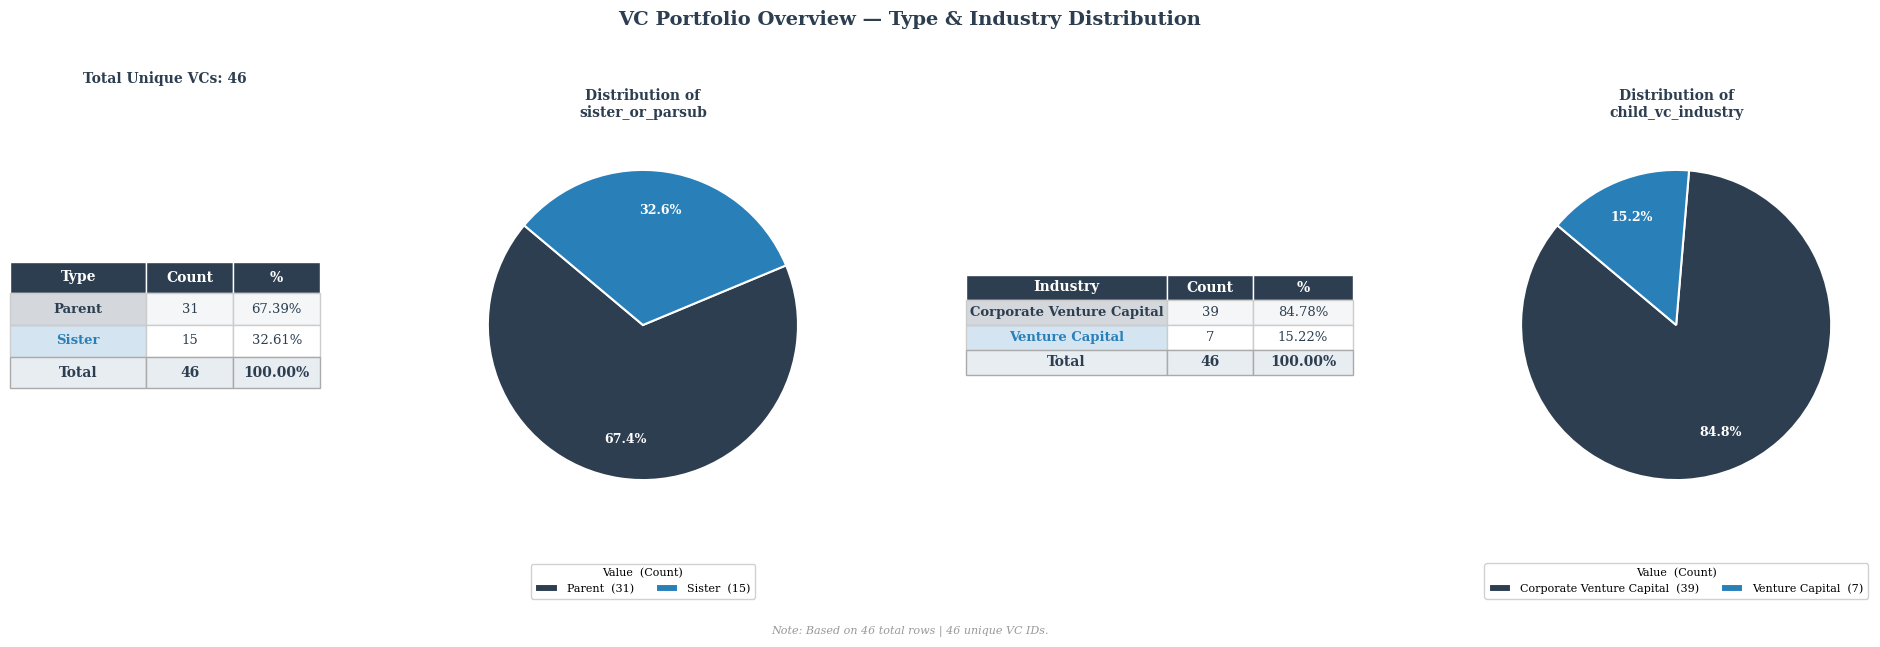

In [274]:
from matplotlib import rcParams
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import itertools

df = df15.copy()

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

# --- Column names (adjust if needed) ---
col_id = v.child_vc_id
col_type = v.sister_or_parsub
col_industry = v.child_vc_industry

# --- Compute stats ---
total_unique = df[col_id].nunique()

# Type counts
type_counts = df[col_type].value_counts(dropna = False)
type_pct = (type_counts / type_counts.sum() * 100).round(2)
type_df = pd.DataFrame({'Value': type_counts.index, 'Count': type_counts.values, 'Percentage': type_pct.values})

# Industry counts
ind_counts = df[col_industry].value_counts(dropna = False)
ind_pct = (ind_counts / ind_counts.sum() * 100).round(2)
ind_df = pd.DataFrame({'Value': ind_counts.index, 'Count': ind_counts.values, 'Percentage': ind_pct.values})

# --- Color palettes ---
type_colors = ['#2C3E50', '#2980B9']  # two colors for sister/parent

base_palette = [
        '#2C3E50', '#2980B9', '#1ABC9C', '#F39C12',
        '#8E44AD', '#E74C3C', '#27AE60', '#D35400',
        '#16A085', '#C0392B', '#7F8C8D', '#6C3483',
        '#1A5276', '#117A65', '#784212', '#4D5656'
]
ind_colors = list(itertools.islice(itertools.cycle(base_palette), len(ind_df)))

# ── Figure layout: 2 rows x 4 cols
# [type_table | type_pie | ind_table | ind_pie]
fig = plt.figure(figsize = (24, max(6.0, len(ind_df) * 0.38 + 3.0)))

gs = gridspec.GridSpec(
        1, 4,
        figure = fig,
        width_ratios = [0.8, 1.0, 1.0, 1.0],
        wspace = 0.35
)

ax_ttype = fig.add_subplot(gs[0])  # type table
ax_ptype = fig.add_subplot(gs[1])  # type pie
ax_tind = fig.add_subplot(gs[2])  # industry table
ax_pind = fig.add_subplot(gs[3])  # industry pie

header_color = '#2C3E50'
row_colors = ['#FFFFFF', '#F4F6F8']


# ────────────────────────────────────────────────
# Helper: draw a styled table on an axis
# ────────────────────────────────────────────────
def draw_table(ax, cell_data, col_labels, colors, col_widths, scale_y = 1.7):
    ax.axis('off')
    # Add totals row
    total_count = sum(row[1] for row in cell_data)  # raw ints needed
    cell_str = [[r[0], f"{r[1]:,}", f"{r[2]:.2f}%"] for r in cell_data]
    cell_str.append(['Total', f"{sum(r[1] for r in cell_data):,}", '100.00%'])

    table = ax.table(
            cellText = cell_str,
            colLabels = col_labels,
            cellLoc = 'center',
            colWidths = col_widths,
            loc = 'center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9.5)
    table.scale(1, scale_y)

    # Header
    for j in range(len(col_labels)):
        cell = table[(0, j)]
        cell.set_facecolor(header_color)
        cell.set_text_props(weight = 'bold', color = 'white', fontsize = 10)
        cell.set_edgecolor('white')

    # Data + total rows
    for i in range(1, len(cell_str) + 1):
        is_total = (i == len(cell_str))
        for j in range(len(col_labels)):
            cell = table[(i, j)]
            cell.set_edgecolor('#CCCCCC')
            if is_total:
                cell.set_facecolor('#E8EDF2')
                cell.set_text_props(weight = 'bold', color = '#2C3E50', fontsize = 10)
                cell.set_edgecolor('#AAAAAA')
            else:
                cell.set_facecolor(row_colors[i % 2])
                if j == 0:
                    cell.set_facecolor(colors[i - 1] + '33')
                    cell.set_text_props(color = colors[i - 1], weight = 'bold', fontsize = 9.5)
                else:
                    cell.set_text_props(color = '#2C3E50')
    return table


# ────────────────────────────────────────────────
# Helper: draw a pie on an axis
# ────────────────────────────────────────────────
def draw_pie(ax, data_df, colors, title):
    wedges, texts, autotexts = ax.pie(
            data_df['Count'],
            labels = None,
            autopct = lambda p: f'{p:.1f}%' if p > 3 else '',
            startangle = 140,
            colors = colors,
            wedgeprops = {'edgecolor': 'white', 'linewidth': 1.5},
            pctdistance = 0.75
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_color('white')
        at.set_fontweight('bold')

    ax.legend(
            wedges,
            [f"{v}  ({c:,})" for v, c in zip(data_df['Value'], data_df['Count'])],
            title = 'Value  (Count)',
            title_fontsize = 8,
            fontsize = 8,
            loc = 'lower center',
            bbox_to_anchor = (0.5, -0.22),
            frameon = True,
            framealpha = 0.9,
            ncol = 2
    )
    ax.set_title(title, fontsize = 10, fontweight = 'bold', color = '#2C3E50', pad = 10)


# ── Type table
type_cell_data = list(zip(type_df['Value'], type_df['Count'], type_df['Percentage']))
draw_table(ax_ttype, type_cell_data, ['Type', 'Count', '%'],
           type_colors, col_widths = [0.44, 0.28, 0.28], scale_y = 1.9)

# Add unique VC count above the table
ax_ttype.set_title(f'Total Unique VCs: {total_unique:,}',
                   fontsize = 10, fontweight = 'bold', color = '#2C3E50', pad = 8)

# ── Type pie
draw_pie(ax_ptype, type_df, type_colors, f'Distribution of\n{col_type}')

# ── Industry table
ind_cell_data = list(zip(ind_df['Value'], ind_df['Count'], ind_df['Percentage']))
draw_table(ax_tind, ind_cell_data, ['Industry', 'Count', '%'],
           ind_colors, col_widths = [0.52, 0.22, 0.26], scale_y = 1.5)

# ── Industry pie
draw_pie(ax_pind, ind_df, ind_colors, f'Distribution of\n{col_industry}')

# --- Suptitle & note ---
fig.suptitle(
        'VC Portfolio Overview — Type & Industry Distribution',
        fontsize = 14, fontweight = 'bold', color = '#2C3E50',
        y = 1.02, fontfamily = 'serif'
)
fig.text(
        0.5, -0.02,
        f'Note: Based on {len(df):,} total rows | {total_unique:,} unique VC IDs.',
        ha = 'center', fontsize = 8, color = '#999999', style = 'italic', fontfamily = 'serif'
)

plt.tight_layout()

output_path = fi.sp100_50  # update as needed
plt.savefig(output_path, format = 'svg', bbox_inches = 'tight', dpi = 300)
print(f"\n✓ Figure saved to: {output_path}")

plt.show()

In [286]:
df15[v.parent_hospital_industry].value_counts()

parent_hospital_industry
Clinics/Outpatient Services         16
Hospitals/Inpatient Services        11
Other Healthcare Services            7
Laboratory Services (Healthcare)     5
Acquirer                             2
Elder and Disabled Care              2
Foundation                           1
Corporation                          1
Name: count, dtype: int64

In [277]:
df15.columns

Index(['child_vc_id', 'parent_hospital_id', 'parent_hospital_industry',
       'sister_or_parsub', 'child_vc_industry', 'parent_hospital_Universe',
       'parent_hospital_PrimaryIndustrySector',
       'parent_hospital_PrimaryIndustryGroup'],
      dtype='object')

In [301]:
df15.to_excel(fi.sp100_70, index = False)

In [303]:
df15

,child_vc_id,parent_hospital_id,parent_hospital_industry,sister_or_parsub,child_vc_industry,parent_hospital_Universe,parent_hospital_PrimaryIndustrySector,parent_hospital_PrimaryIndustryGroup
0,434783-53,166514-86,Hospitals/Inpatient Services,Parent,Corporate Venture Capital,M&A,Healthcare,Healthcare Services
1,433943-74,55165-33,Acquirer,Parent,Corporate Venture Capital,NaN,NaN,NaN
2,56040-94,56084-95,Clinics/Outpatient Services,Parent,Corporate Venture Capital,NaN,NaN,NaN
3,433710-46,50987-17,Hospitals/Inpatient Services,Parent,Venture Capital,NaN,NaN,NaN
4,55757-98,51726-52,Clinics/Outpatient Services,Parent,Venture Capital,Venture Capital,Healthcare,Healthcare Services
5,149695-84,126530-83,Other Healthcare Services,Parent,Corporate Venture Capital,"M&A, Private Equity",Healthcare,Healthcare Services
6,432514-09,55280-53,Laboratory Services (Healthcare),Parent,Corporate Venture Capital,"Publicly Listed, Venture Capital",Healthcare,Healthcare Services
7,54810-10,54249-85,Laboratory Services (Healthcare),Parent,Corporate Venture Capital,M&A,Healthcare,Healthcare Services
8,51450-31,150350-41,Hospitals/Inpatient Services,Parent,Venture Capital,M&A,Healthcare,Healthcare Services
9,521254-27,54999-82,Clinics/Outpatient Services,Parent,Corporate Venture Capital,"M&A, Private Equity, Publicly Listed, Venture ...",Healthcare,Healthcare Services



✓ Figure saved to: /sharedata/camm/c_projects/i100_g7__VC_arms/g32_results_plot_with_tables/sp100_60.svg


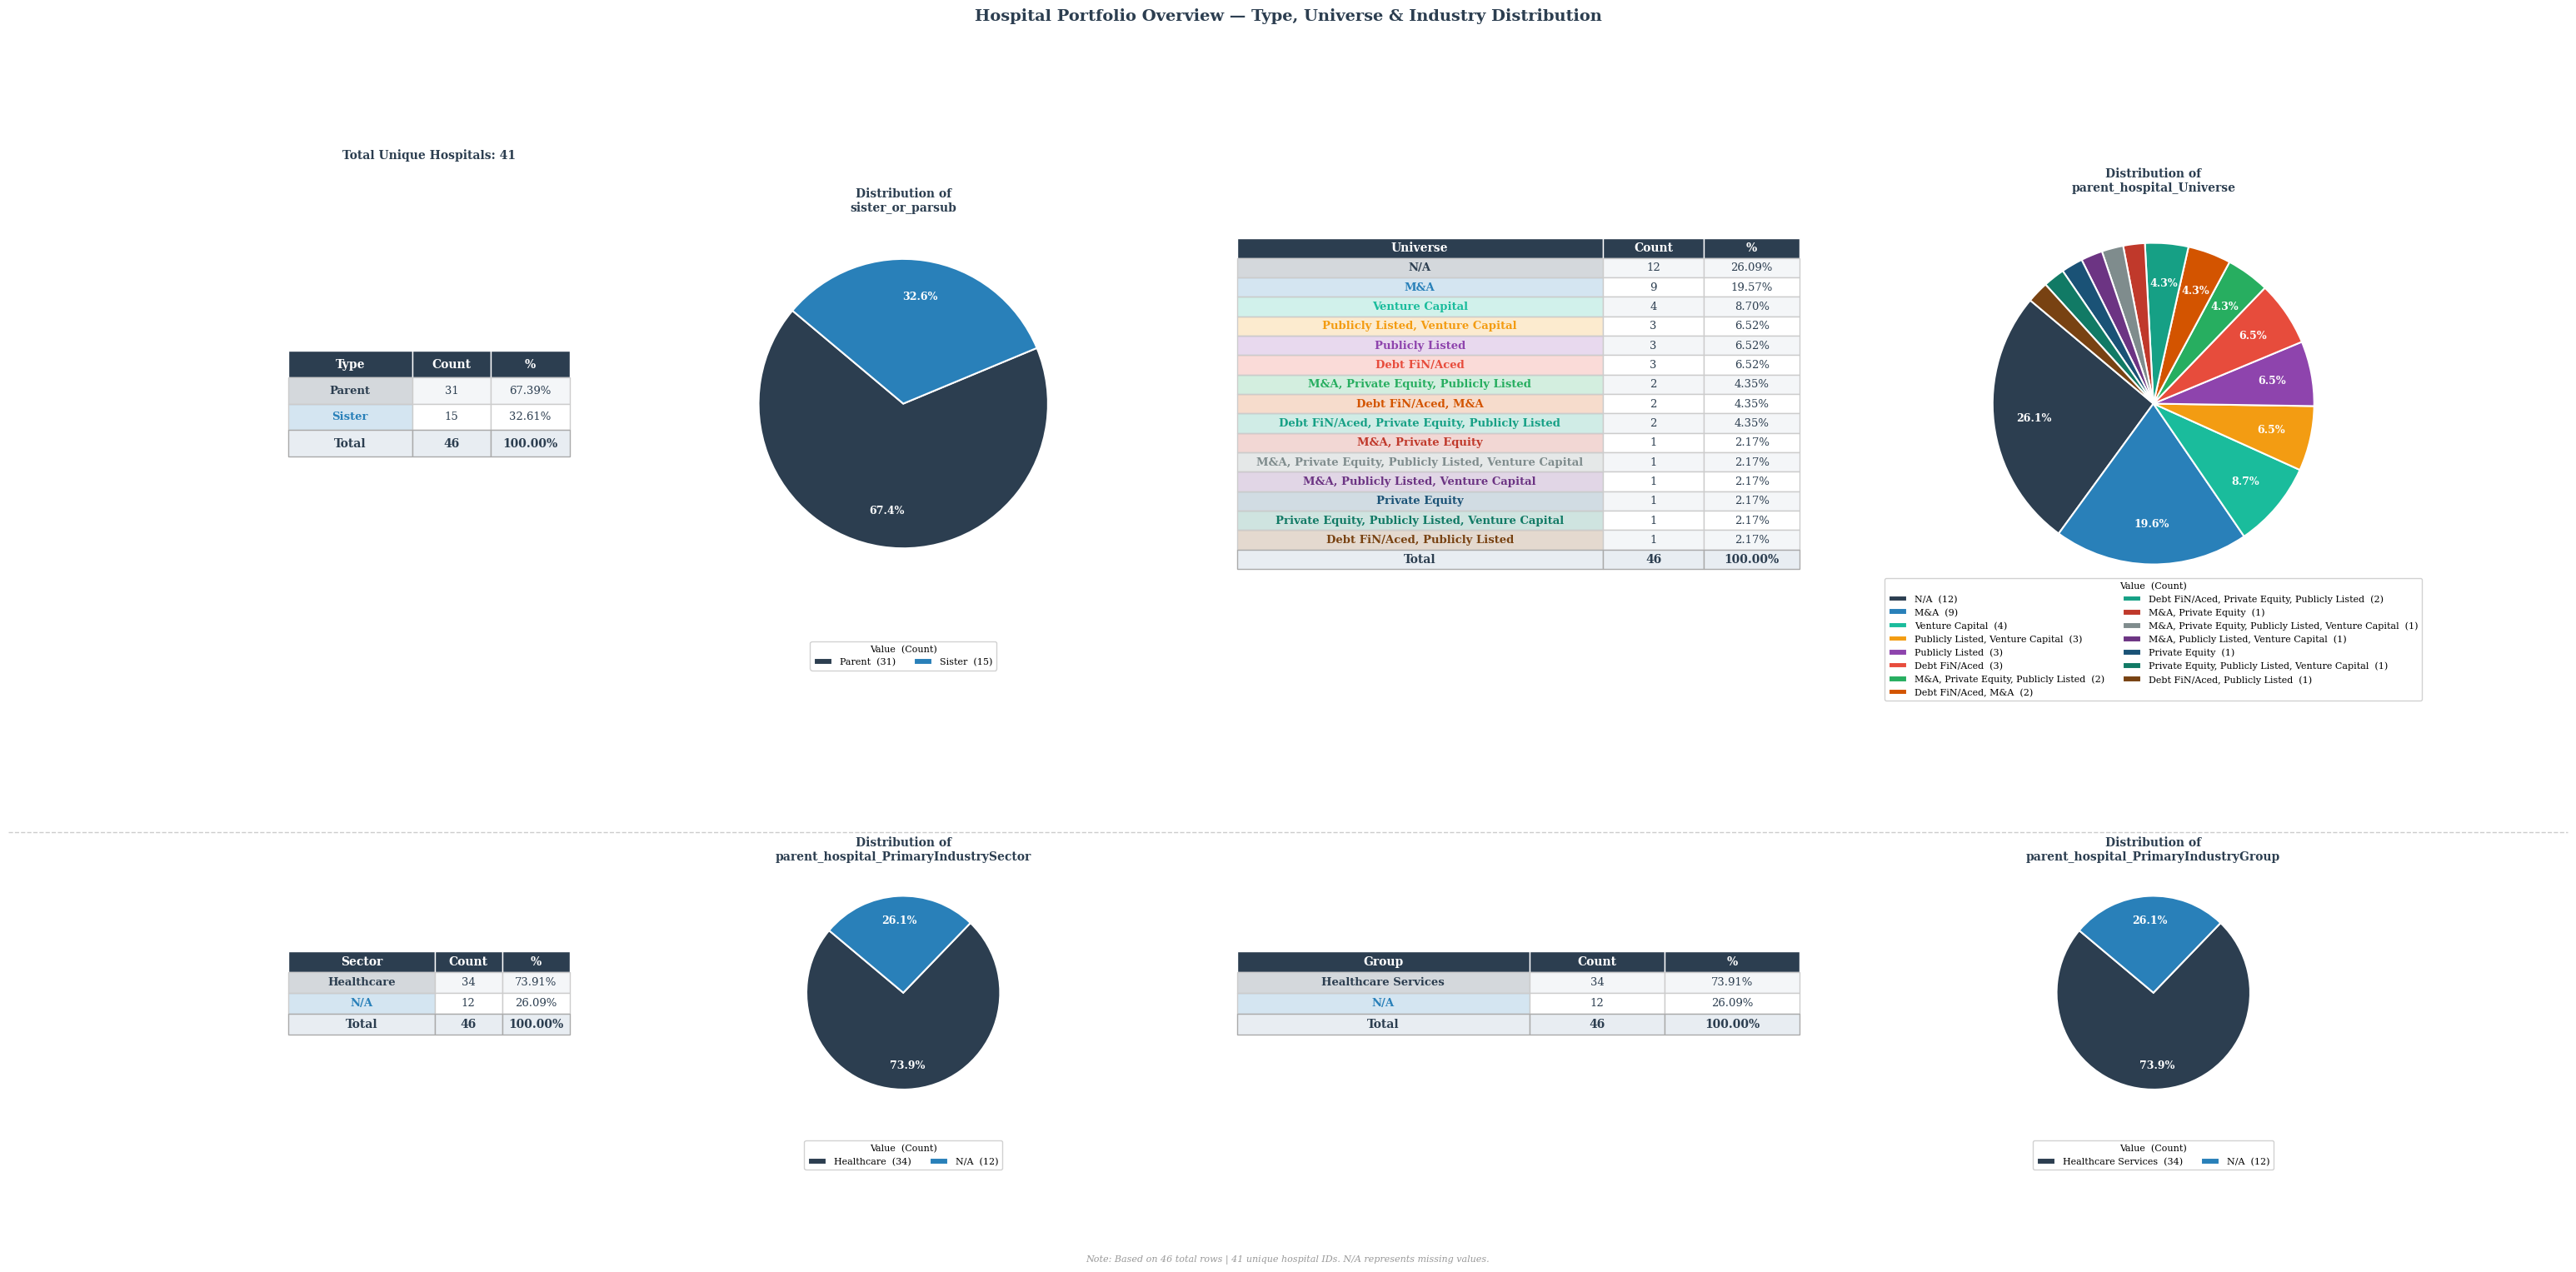

In [291]:
from matplotlib import rcParams
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import itertools

df = df15.copy()

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

# --- Column names ---
col_id = v.parent_hospital_id
col_type = v.sister_or_parsub
col_universe = 'parent_hospital_' + v.universe__pb
col_sector = 'parent_hospital_' + v.primary_industry_sec__pb
col_group = 'parent_hospital_' + v.primary_industry_gp__pb


# --- Helper: compute freq df ---
def make_freq_df(series):
    counts = series.value_counts(dropna = False)
    counts.index = counts.index.astype(str).str.replace('<NA>', 'N/A').str.replace('nan', 'N/A')
    pct = (counts / counts.sum() * 100).round(2)
    return pd.DataFrame({'Value': counts.index, 'Count': counts.values, 'Percentage': pct.values})


type_df = make_freq_df(df[col_type])
universe_df = make_freq_df(df[col_universe])
sector_df = make_freq_df(df[col_sector])
group_df = make_freq_df(df[col_group])

total_unique = df[col_id].nunique()

# --- Color palettes ---
base_palette = [
        '#2C3E50', '#2980B9', '#1ABC9C', '#F39C12',
        '#8E44AD', '#E74C3C', '#27AE60', '#D35400',
        '#16A085', '#C0392B', '#7F8C8D', '#6C3483',
        '#1A5276', '#117A65', '#784212', '#4D5656'
]


def make_colors(n):
    return list(itertools.islice(itertools.cycle(base_palette), n))


type_colors = make_colors(len(type_df))
universe_colors = make_colors(len(universe_df))
sector_colors = make_colors(len(sector_df))
group_colors = make_colors(len(group_df))

# ─────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────
header_color = '#2C3E50'
row_colors = ['#FFFFFF', '#F4F6F8']


def draw_table(ax, freq_df, colors, col_labels, col_widths, scale_y = 1.7, title = None):
    ax.axis('off')
    cell_data = [[str(r['Value']), f"{r['Count']:,}", f"{r['Percentage']:.2f}%"]
                 for _, r in freq_df.iterrows()]
    cell_data.append(['Total', f"{freq_df['Count'].sum():,}", '100.00%'])

    table = ax.table(
            cellText = cell_data,
            colLabels = col_labels,
            cellLoc = 'center',
            colWidths = col_widths,
            loc = 'center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9.5)
    table.scale(1, scale_y)

    for j in range(len(col_labels)):
        cell = table[(0, j)]
        cell.set_facecolor(header_color)
        cell.set_text_props(weight = 'bold', color = 'white', fontsize = 10)
        cell.set_edgecolor('white')

    for i in range(1, len(cell_data) + 1):
        is_total = (i == len(cell_data))
        for j in range(len(col_labels)):
            cell = table[(i, j)]
            cell.set_edgecolor('#CCCCCC')
            if is_total:
                cell.set_facecolor('#E8EDF2')
                cell.set_text_props(weight = 'bold', color = '#2C3E50', fontsize = 10)
                cell.set_edgecolor('#AAAAAA')
            else:
                cell.set_facecolor(row_colors[i % 2])
                if j == 0:
                    cell.set_facecolor(colors[i - 1] + '33')
                    cell.set_text_props(color = colors[i - 1], weight = 'bold', fontsize = 9.5)
                else:
                    cell.set_text_props(color = '#2C3E50')

    if title:
        ax.set_title(title, fontsize = 10, fontweight = 'bold', color = '#2C3E50', pad = 8)


def draw_pie(ax, freq_df, colors, title):
    wedges, texts, autotexts = ax.pie(
            freq_df['Count'],
            labels = None,
            autopct = lambda p: f'{p:.1f}%' if p > 3 else '',
            startangle = 140,
            colors = colors,
            wedgeprops = {'edgecolor': 'white', 'linewidth': 1.5},
            pctdistance = 0.75
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_color('white')
        at.set_fontweight('bold')

    ax.legend(
            wedges,
            [f"{v}  ({c:,})" for v, c in zip(freq_df['Value'], freq_df['Count'])],
            title = 'Value  (Count)',
            title_fontsize = 8,
            fontsize = 8,
            loc = 'lower center',
            bbox_to_anchor = (0.5, -0.25),
            frameon = True,
            framealpha = 0.9,
            ncol = 2
    )
    ax.set_title(title, fontsize = 10, fontweight = 'bold', color = '#2C3E50', pad = 10)


# ─────────────────────────────────────────────
# Layout
# ─────────────────────────────────────────────
row_h = lambda d: max(5.0, len(d) * 0.45 + 3.0)
row0_h = row_h(max([type_df, universe_df], key = len))
row1_h = row_h(max([sector_df, group_df], key = len))
fig_h = row0_h + row1_h

fig = plt.figure(figsize = (32, fig_h))  # ← widened to 32

gs = gridspec.GridSpec(
        2, 4,
        figure = fig,
        height_ratios = [row0_h, row1_h],
        # ← type pair gets less width, universe pair gets more
        width_ratios = [0.7, 0.9, 1.4, 1.0],
        hspace = 0.65,
        wspace = 0.38
)

# Row 0
ax_ttype = fig.add_subplot(gs[0, 0])
ax_ptype = fig.add_subplot(gs[0, 1])
ax_tuniverse = fig.add_subplot(gs[0, 2])  # ← gets 1.4x width
ax_puniverse = fig.add_subplot(gs[0, 3])

# Row 1
ax_tsector = fig.add_subplot(gs[1, 0])
ax_psector = fig.add_subplot(gs[1, 1])
ax_tgroup = fig.add_subplot(gs[1, 2])
ax_pgroup = fig.add_subplot(gs[1, 3])

# ── Row 0: Type & Universe ──
draw_table(ax_ttype, type_df, type_colors,
           ['Type', 'Count', '%'], [0.44, 0.28, 0.28],
           scale_y = 1.9, title = f'Total Unique Hospitals: {total_unique:,}')
draw_pie(ax_ptype, type_df, type_colors, f'Distribution of\n{col_type}')

draw_table(ax_tuniverse, universe_df, universe_colors,
           ['Universe', 'Count', '%'], [0.65, 0.18, 0.17],  # ← Value col = 65%
           scale_y = 1.4)
draw_pie(ax_puniverse, universe_df, universe_colors, f'Distribution of\n{col_universe}')

# ── Row 1: Sector & Group ──
draw_table(ax_tsector, sector_df, sector_colors,
           ['Sector', 'Count', '%'], [0.52, 0.24, 0.24], scale_y = 1.5)
draw_pie(ax_psector, sector_df, sector_colors, f'Distribution of\n{col_sector}')

draw_table(ax_tgroup, group_df, group_colors,
           ['Group', 'Count', '%'], [0.52, 0.24, 0.24], scale_y = 1.5)
draw_pie(ax_pgroup, group_df, group_colors, f'Distribution of\n{col_group}')

# ── Row divider line ──
divider_y = row1_h / fig_h
fig.add_artist(plt.Line2D(
        [0.02, 0.98], [divider_y, divider_y],
        transform = fig.transFigure,
        color = '#CCCCCC', linewidth = 1.0, linestyle = '--'
))

# --- Suptitle & note ---
fig.suptitle(
        'Hospital Portfolio Overview — Type, Universe & Industry Distribution',
        fontsize = 14, fontweight = 'bold', color = '#2C3E50',
        y = 1.01, fontfamily = 'serif'
)
fig.text(
        0.5, -0.01,
        f'Note: Based on {len(df):,} total rows | {total_unique:,} unique hospital IDs. N/A represents missing values.',
        ha = 'center', fontsize = 8, color = '#999999', style = 'italic', fontfamily = 'serif'
)

plt.tight_layout()

output_path = fi.sp100_60
plt.savefig(output_path, format = 'svg', bbox_inches = 'tight', dpi = 300)
print(f"\n✓ Figure saved to: {output_path}")

plt.show()

In [290]:
df15[v.parent_hospital_universe].value_counts()

parent_hospital_Universe
M&A                                                      9
Venture Capital                                          4
Publicly Listed, Venture Capital                         3
Publicly Listed                                          3
Debt Financed                                            3
M&A, Private Equity, Publicly Listed                     2
Debt Financed, M&A                                       2
Debt Financed, Private Equity, Publicly Listed           2
M&A, Private Equity                                      1
M&A, Private Equity, Publicly Listed, Venture Capital    1
M&A, Publicly Listed, Venture Capital                    1
Private Equity                                           1
Private Equity, Publicly Listed, Venture Capital         1
Debt Financed, Publicly Listed                           1
Name: count, dtype: int64


✓ Diagram saved to: /sharedata/camm/c_projects/i100_g7__VC_arms/g32_results_plot_with_tables/sp100_65.svg


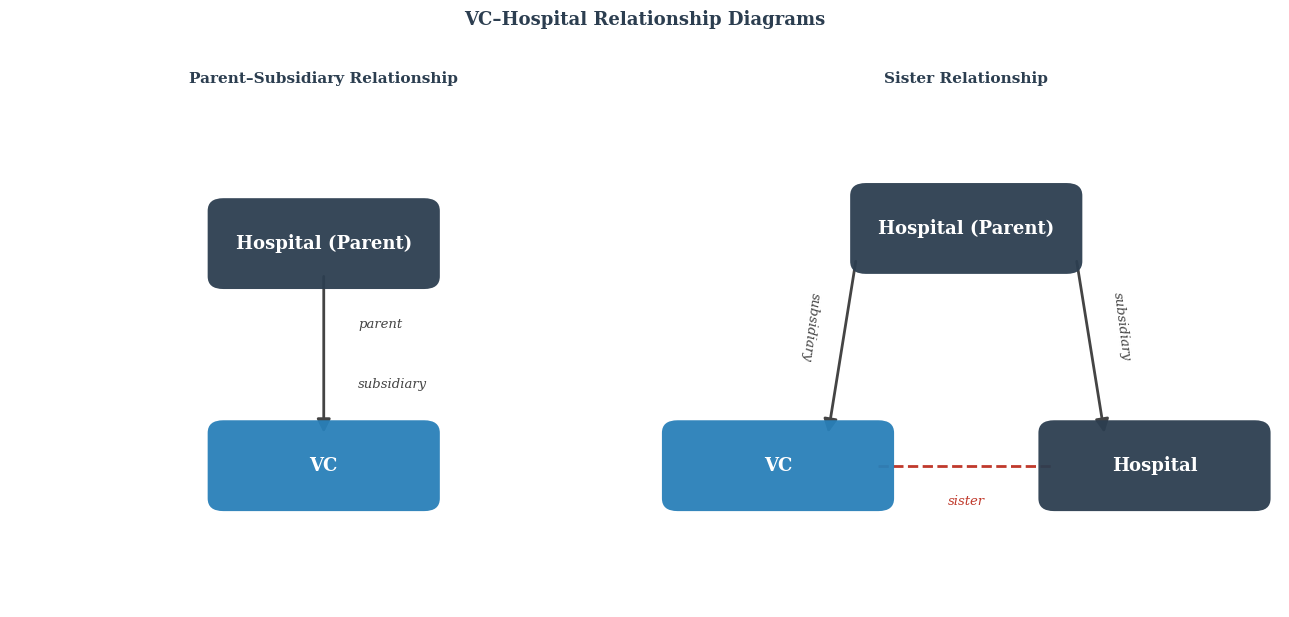

In [295]:
from matplotlib import rcParams
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (13, 6))

# ─────────────────────────────────────────────
# Shared style constants
# ─────────────────────────────────────────────
BOX_W = 0.32
BOX_H = 0.13
C_HOSP = '#2C3E50'
C_VC = '#2980B9'
C_ARROW = '#444444'
C_SISTER = '#C0392B'
FONT_BOX = dict(fontsize = 13, fontweight = 'bold', color = 'white',
                ha = 'center', va = 'center', fontfamily = 'serif')


def draw_box(ax, cx, cy, label, color):
    rect = mpatches.FancyBboxPatch(
            (cx - BOX_W / 2, cy - BOX_H / 2), BOX_W, BOX_H,
            boxstyle = 'round,pad=0.025',
            linewidth = 0,
            edgecolor = 'none',
            facecolor = color,
            zorder = 3,
            alpha = 0.95
    )
    ax.add_patch(rect)
    ax.text(cx, cy, label, **FONT_BOX, zorder = 4)


def solid_arrow(ax, x1, y1, x2, y2, color = C_ARROW):
    """Clean straight arrow using annotate."""
    ax.annotate(
            '', xy = (x2, y2), xytext = (x1, y1),
            arrowprops = dict(
                    arrowstyle = '-|>',
                    color = color,
                    lw = 2.0,
                    mutation_scale = 20,
                    shrinkA = 0,
                    shrinkB = 0
            ),
            zorder = 2
    )


def dashed_line(ax, x1, y1, x2, y2, color = C_SISTER):
    ax.plot([x1, x2], [y1, y2],
            linestyle = '--', color = color, lw = 2.0, zorder = 2)


def label_on_line(ax, x, y, text, color = C_ARROW, rotation = 0, offset = (0, 0)):
    ax.text(x + offset[0], y + offset[1], text,
            fontsize = 9.5, color = color, style = 'italic',
            rotation = rotation, ha = 'center', va = 'center',
            fontfamily = 'serif',
            bbox = dict(facecolor = 'white', edgecolor = 'none', pad = 1.5, alpha = 0.85),
            zorder = 5)


# ═══════════════════════════════════════════════════════
# DIAGRAM 1 — Parent–Subsidiary  (Hospital parent of VC)
# ═══════════════════════════════════════════════════════
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')
ax1.set_title('Parent–Subsidiary Relationship',
              fontsize = 11, fontweight = 'bold', color = '#2C3E50',
              pad = 14, fontfamily = 'serif')

H_CX, H_CY = 0.50, 0.72
V_CX, V_CY = 0.50, 0.28

draw_box(ax1, H_CX, H_CY, 'Hospital (Parent)', C_HOSP)
draw_box(ax1, V_CX, V_CY, 'VC', C_VC)

# Arrow from bottom of Hospital to top of VC
solid_arrow(ax1,
            H_CX, H_CY - BOX_H / 2,
            V_CX, V_CY + BOX_H / 2)

# Labels — NOT rotated
mid_y = (H_CY + V_CY) / 2
label_on_line(ax1, H_CX, mid_y + 0.06, 'parent',
              color = C_ARROW, rotation = 0, offset = (0.09, 0))
label_on_line(ax1, H_CX, mid_y - 0.06, 'subsidiary',
              color = C_ARROW, rotation = 0, offset = (0.11, 0))

# ═══════════════════════════════════════════════════════
# DIAGRAM 2 — Sister relationship
#   Hospital (Parent) at top
#   VC (left) and Hospital (right) as subsidiaries
#   dashed sister line between VC and Hospital
# ═══════════════════════════════════════════════════════
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')
ax2.set_title('Sister Relationship',
              fontsize = 11, fontweight = 'bold', color = '#2C3E50',
              pad = 14, fontfamily = 'serif')

P_CX, P_CY = 0.50, 0.75
VC_CX, VC_CY = 0.20, 0.28
S_CX, S_CY = 0.80, 0.28

draw_box(ax2, P_CX, P_CY, 'Hospital (Parent)', C_HOSP)
draw_box(ax2, VC_CX, VC_CY, 'VC', C_VC)
draw_box(ax2, S_CX, S_CY, 'Hospital', C_HOSP)

# Arrow: parent → VC (left diagonal)
x1_l = P_CX - BOX_W * 0.55
y1_l = P_CY - BOX_H / 2
x2_l = VC_CX + BOX_W * 0.25
y2_l = VC_CY + BOX_H / 2
solid_arrow(ax2, x1_l, y1_l, x2_l, y2_l)

# Arrow: parent → Hospital subsidiary (right diagonal)
x1_r = P_CX + BOX_W * 0.55
y1_r = P_CY - BOX_H / 2
x2_r = S_CX - BOX_W * 0.25
y2_r = S_CY + BOX_H / 2
solid_arrow(ax2, x1_r, y1_r, x2_r, y2_r)

# "subsidiary" labels on the two diagonal arrows — rotated to match line angle
import numpy as np

angle_l = np.degrees(np.arctan2(y2_l - y1_l, x2_l - x1_l))
angle_r = np.degrees(np.arctan2(y2_r - y1_r, x2_r - x1_r))

mid_xl = (x1_l + x2_l) / 2
mid_yl = (y1_l + y2_l) / 2
mid_xr = (x1_r + x2_r) / 2
mid_yr = (y1_r + y2_r) / 2

label_on_line(ax2, mid_xl, mid_yl, 'subsidiary',
              color = C_ARROW, rotation = angle_l, offset = (-0.05, 0.04))
label_on_line(ax2, mid_xr, mid_yr, 'subsidiary',
              color = C_ARROW, rotation = angle_r, offset = (0.05, 0.04))

# Dashed sister line between VC and Hospital subsidiaries
dashed_line(ax2,
            VC_CX + BOX_W / 2, VC_CY,
            S_CX - BOX_W / 2, S_CY)

# "sister" label in the middle of the dashed line
label_on_line(ax2,
              (VC_CX + BOX_W / 2 + S_CX - BOX_W / 2) / 2,
              VC_CY,
              'sister', color = C_SISTER, rotation = 0, offset = (0, -0.07))

# ─────────────────────────────────────────────
# Suptitle & save
# ─────────────────────────────────────────────
fig.suptitle(
        'VC–Hospital Relationship Diagrams',
        fontsize = 13, fontweight = 'bold', color = '#2C3E50',
        y = 1.02, fontfamily = 'serif'
)

plt.tight_layout()

output_path = fi.sp100_65
plt.savefig(output_path, format = 'svg', bbox_inches = 'tight', dpi = 300)
print(f"\n✓ Diagram saved to: {output_path}")

plt.show()

# MATCHING WITH STEPSTONE

In [ ]:
df = pd.read_excel(
        'a00_alias__sharedata_camm/d000_projects_data/i83_g7__VC_arms_data/inp_data/pb_ss_investor_match.xlsx')